## Group-level RSA (CWS vs. CWNS) on GLMsingle single-trial ROI RDMs

Compares CWS and CWNS on the per-subject, per-ROI crossnobis RDMs computed by `GLMsingle_rsa-roi.py`. Two complementary analyses:
1. **Model-fit comparison** (primary): correlate each subject's empirical RDM (per ROI) against model RDMs -- categorical (SNR level, syllable identity, speaker identity) and, when restricted to `NOISE_LEVEL_TAG = 'Q'`, acoustic (Praat-derived speech-metric features: F0, intensity, formants, from `FMRI_STIM_Q_speech_metrics.xlsx`) -- then compare model-fit strength between groups via subject-level bootstrap.
2. **Direct RDM comparison** (descriptive): compare CWS-mean vs. CWNS-mean RDM per ROI directly, no categorical models involved.
3. **Noise ceiling** (per ROI x per group -- see below): estimates the best model-fit correlation achievable in each ROI given the noise in the empirical data itself, independent of any model (Nili et al. 2014). Shown as a shaded band on the box+strip plots so each model-fit value can be read against what's actually achievable there. CWS (n=7) will show a wider/noisier ceiling than CWNS (n=23) -- expected given the sample-size difference, not a bug.

**Multiple comparisons:** the bootstrap tests below report both the raw, uncorrected two-sided empirical p-value AND a `p_fdr` column (Benjamini-Hochberg FDR, applied once globally across every ROI x model test in each table -- up to 20 ROIs x 7 models per table). Box/strip-plot significance asterisks use `p_fdr < 0.05`; the raw `p_value` is kept in the saved CSVs and the summary printouts below for reference.

In [1]:
import os
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rsatoolbox
from scipy.spatial.distance import pdist, squareform
from statsmodels.stats.multitest import multipletests

### Set parameters

In [2]:
bidsroot = os.path.join('/bgfs/bchandrasekaran/krs228/data/',
                        'SSP/',
                        'data_bids')
glmsingle_dir = os.path.join(bidsroot, 'derivatives', 'glmsingle')

RDM_METHOD = 'crossnobis'
NOISE_LEVEL_TAG = 'Q'  # matches GLMsingle_rsa-roi.py's --noise_level output tag ('all' or e.g. 'Q')

# Acoustic model RDMs (below) require NOISE_LEVEL_TAG='Q' -- the only noise level the speech
# metrics sheet has measurements for (noise is added digitally on top of the same clean
# recording, so acoustic properties are only ever measured once per syllable/speaker).
ACOUSTIC_METRICS_XLSX = os.path.join('..', 'FMRI_STIM_Q_speech_metrics.xlsx')

rdm_dir = os.path.join(glmsingle_dir, f'rsa-roi_glmsingle_rdmcalc-{RDM_METHOD}')
print('rdm_dir:', rdm_dir)

# Ordered all-L-then-all-R (mirrored, same relative region order in both halves) rather than
# per-network L/R blocks -- kept in sync with GLMsingle_mask-betas.py / GLMsingle_rsa-roi.py.
CORTICAL_ROI_LIST = [
    'L-HG', 'L-PT', 'L-PP', 'L-STGp', 'L-STGa', 'L-ParsOp', 'L-ParsTri', 'L-SMGa', 'L-SMGp', 'L-Ang',
    'R-HG', 'R-PT', 'R-PP', 'R-STGp', 'R-STGa', 'R-ParsOp', 'R-ParsTri', 'R-SMGa', 'R-SMGp', 'R-Ang',
]

# base region order (no hemisphere prefix), for the hemisphere-hue group-specific plots below
BASE_REGION_ORDER = [roi.split('-', 1)[1] for roi in CORTICAL_ROI_LIST if roi.startswith('L-')]

N_BOOT = 10000
RNG = np.random.default_rng(0)

out_dir = os.path.join(glmsingle_dir, 'rsa-group_glmsingle')
os.makedirs(out_dir, exist_ok=True)

rdm_dir: /bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/glmsingle/rsa-roi_glmsingle_rdmcalc-crossnobis


### Load participants and group membership

In [3]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')

# case-/whitespace-normalized group comparison -- same fix already applied in
# univariate_group-level.ipynb, since participants.tsv's group column has been observed with
# inconsistent casing (e.g. 'CWS' vs 'cws').
group_norm = participants_df.group.str.strip().str.lower()
sub_list_cwns_all = list(participants_df.participant_id[group_norm == 'control'])
sub_list_cws_all = list(participants_df.participant_id[group_norm == 'cws'])

# restrict to subjects that actually have an RDM file -- not every subject in participants.tsv
# has usable GLMsingle output (e.g. single-run subjects only get the degraded TYPEB estimate,
# which GLMsingle_mask-betas.py already refuses to mask for RSA).
rdm_fpaths = sorted(glob(os.path.join(rdm_dir, f'sub-*_glmsingle_cortical_{RDM_METHOD}_noiselevel-{NOISE_LEVEL_TAG}_rdms.hdf5')))
if len(rdm_fpaths) == 0:
    raise RuntimeError(
        f"No RDM files found matching noiselevel-{NOISE_LEVEL_TAG} in {rdm_dir} -- if "
        f"NOISE_LEVEL_TAG='{NOISE_LEVEL_TAG}' was just changed, make sure "
        f"GLMsingle_rsa-roi.py has actually been (re-)run with --noise_level={NOISE_LEVEL_TAG} "
        "for at least one subject first; its output filenames encode this tag "
        "('noiselevel-Q' for --noise_level=Q, 'noiselevel-all' if --noise_level was omitted)."
    )

subs_with_rdms = set()
for f in rdm_fpaths:
    fname = os.path.basename(f)
    sub_id = fname.split('_')[0].replace('sub-', '')
    subs_with_rdms.add(f'sub-{sub_id}')

sub_list_cwns = [s for s in sub_list_cwns_all if s in subs_with_rdms]
sub_list_cws = [s for s in sub_list_cws_all if s in subs_with_rdms]

if len(sub_list_cwns) == 0 and len(sub_list_cws) == 0:
    raise RuntimeError(
        f"{len(rdm_fpaths)} RDM file(s) found, but none matched a subject in "
        "participants.tsv after group filtering -- check participant_id naming/casing "
        "consistency between the RDM filenames and participants.tsv."
    )

print(f'{len(rdm_fpaths)} RDM files found')
print(f'CWNS: {len(sub_list_cwns)}/{len(sub_list_cwns_all)} have RDMs')
print(f'CWS: {len(sub_list_cws)}/{len(sub_list_cws_all)} have RDMs')

30 RDM files found
CWNS: 23/43 have RDMs
CWS: 7/14 have RDMs


### Load each subject's RDMs

In [4]:
def load_subject_rdms(sub_id):
    fpath = os.path.join(rdm_dir, f'{sub_id}_glmsingle_cortical_{RDM_METHOD}_noiselevel-{NOISE_LEVEL_TAG}_rdms.hdf5')
    # NOTE: rsatoolbox's exact load function/path is not independently confirmed against an
    # installed version (none available locally) -- rsatoolbox.rdm.rdms.load_rdm is the
    # symmetric counterpart to rsatoolbox.rdm.rdms.concat, which GLMsingle_rsa-roi.py already
    # uses successfully to save these files. Confirm this exact call on first real run; if it
    # differs, this is the one line to fix.
    return rsatoolbox.rdm.rdms.load_rdm(fpath, file_type='hdf5')


all_subs = sub_list_cwns + sub_list_cws
subject_rdms = {}
for sub_id in all_subs:
    subject_rdms[sub_id] = load_subject_rdms(sub_id)

print(f'Loaded RDMs for {len(subject_rdms)} subjects')

Loaded RDMs for 30 subjects


### Categorical model RDMs (SNR / syllable / speaker)

In [5]:
def build_categorical_model_rdms(pattern_labels):
    """Build SNR/syllable/speaker categorical model RDMs (0 if the two stimuli match on that
    dimension, 1 if they differ), sized and ORDERED to exactly match `pattern_labels` -- the
    actual condition order taken from a loaded empirical RDM's pattern_descriptors, not a
    freshly re-derived list. The model and empirical RDMs' row/column order must match exactly
    for rsatoolbox.rdm.compare() to compare like-for-like conditions.

    Each condition label is expected to be 'SYLLABLE_SPEAKER_NOISELEVEL' (e.g. 'BA_F1_Q'), per
    GLMsingle_first-level.py's build_condition_labels(). Fixes the copy-paste bug in the old
    group_level_rsa_searchlight_WIP.ipynb, where the talker/speaker model RDM was assigned into
    the syllable_rdms variable instead of its own.
    """
    n = len(pattern_labels)
    parsed = [label.split('_') for label in pattern_labels]
    for p in parsed:
        assert len(p) == 3, f"expected 'syllable_speaker_noiselevel', got {p!r}"
    syllables = [p[0] for p in parsed]
    speakers = [p[1] for p in parsed]
    noise_levels = [p[2] for p in parsed]

    model_rdms = {}
    model_rdms['syllable'] = np.array([[0 if syllables[i] == syllables[j] else 1
                                        for j in range(n)] for i in range(n)])
    model_rdms['speaker'] = np.array([[0 if speakers[i] == speakers[j] else 1
                                       for j in range(n)] for i in range(n)])

    # SNR model is degenerate (all-zero, no variance to model) if every trial shares the same
    # noise level -- e.g. a noiselevel-restricted (Q-only) RDM. Skip it automatically rather
    # than including a meaningless all-zero model, instead of hardcoding per noise-level-tag.
    if len(set(noise_levels)) > 1:
        model_rdms['snr'] = np.array([[0 if noise_levels[i] == noise_levels[j] else 1
                                       for j in range(n)] for i in range(n)])
    else:
        print(f'Only one noise level ({noise_levels[0]}) present -- skipping the degenerate SNR model.')

    return model_rdms


# pattern order is assumed identical across subjects/ROIs (same fixed condition design for
# everyone) -- take it from the first subject's first ROI as the reference.
example_rdms = next(iter(subject_rdms.values()))
example_roi_rdm = example_rdms.subset('ROI', CORTICAL_ROI_LIST[0])
# NOTE: pattern_descriptors key name ('stimulus') matches the `descriptor='stimulus'` used when
# building these RDMs in GLMsingle_rsa-roi.py's calc_rdm() call -- confirm on first real run.
pattern_labels = list(example_roi_rdm.pattern_descriptors['stimulus'])
print(f'{len(pattern_labels)} conditions per RDM:', pattern_labels[:5], '...')

categorical_model_rdms = build_categorical_model_rdms(pattern_labels)
print('models built:', list(categorical_model_rdms.keys()))

16 conditions per RDM: ['BA_F1_Q', 'BA_F2_Q', 'BA_M1_Q', 'BA_M2_Q', 'DA_F1_Q'] ...
Only one noise level (Q) present -- skipping the degenerate SNR model.
models built: ['syllable', 'speaker']


### Acoustic model RDMs (from Praat-derived speech metrics)

Builds continuous-valued model RDMs from `FMRI_STIM_Q_speech_metrics.xlsx` (added to the repo
root) -- Euclidean distance on z-scored acoustic features (F0, intensity, F1/F2 formants), both as
one combined `acoustic` model and as separate per-dimension sub-models (`acoustic_f0`,
`acoustic_intensity`, `acoustic_formants`). `DURATION`/`VOWEL_DURATION` are excluded -- they're
numerically identical for every stimulus in the sheet (single-syllable CV recordings, so the
whole-utterance and vowel intervals coincide), so including both would just double-weight one
real dimension against the others without adding any real discriminative information.

**Only valid for `NOISE_LEVEL_TAG = 'Q'`** -- the sheet only has acoustic measurements for the
`Q` noise level (noise is added digitally on top of the same clean recording), so these models
are skipped (with a printed message) for any other `NOISE_LEVEL_TAG`, rather than assuming
acoustic properties are noise-invariant.

In [6]:
ACOUSTIC_FEATURE_GROUPS = {
    'f0': ['MEAN_F0', 'STD_F0', 'MIN_F0', 'MAX_F0'],
    'intensity': ['MEAN_INTENSITY', 'STD_INTENSITY', 'MIN_INTENSITY', 'MAX_INTENSITY'],
    'formants': ['MEAN_F1', 'STD_F1', 'MIN_F1', 'MAX_F1', 'MEAN_F2', 'STD_F2', 'MIN_F2', 'MAX_F2'],
    # 'duration' deliberately excluded: DURATION and VOWEL_DURATION are numerically identical
    # for every stimulus (single-syllable CV recordings), so together they'd just double-weight
    # one real dimension against F0/intensity/formants without adding discriminative information.
}


def load_acoustic_features(xlsx_path):
    """Load the Praat-derived speech-metrics sheet, indexed by (syllable, speaker) -- the sheet
    only has one row per syllable x speaker (measured at noise_level 'Q', the only level
    acoustic properties were measured for; noise is added digitally on top of the same clean
    recording, so the underlying speech acoustics don't change across noise level).

    NOTE: the sheet's 'VOWEL' column is -- despite the name -- a Praat interval string like
    'DURATION'/'VOWEL_DURATION', not a vowel-identity label (confirmed: it differs from
    VOWEL_DURATION on every row). Most likely the narrower sub-window Praat used to sample
    F1/F2/F0 away from formant-transition edges. Not used as a feature here. DURATION and
    VOWEL_DURATION themselves are also not parsed out -- they're numerically identical for
    every stimulus (see ACOUSTIC_FEATURE_GROUPS above), so neither is used as a feature either.
    """
    df = pd.read_excel(xlsx_path)
    df['stimulus'] = df['FILE_NAME'].str.replace('.wav', '', regex=False)
    df[['syllable', 'speaker', 'noise_level']] = df['stimulus'].str.split('_', expand=True)
    return df.set_index(['syllable', 'speaker'])


def build_acoustic_model_rdms(pattern_labels, acoustic_df):
    """Continuous-valued model RDMs (Euclidean distance on z-scored features) from the Praat
    speech-metrics sheet. Only valid when every condition in `pattern_labels` is noise_level
    'Q' -- the only level acoustic features were measured for -- so this returns {} (with a
    printed message) otherwise, mirroring build_categorical_model_rdms' degenerate-model-skip
    convention rather than assuming acoustic properties are noise-invariant.
    """
    parsed = [label.split('_') for label in pattern_labels]
    noise_levels = {p[2] for p in parsed}
    if noise_levels != {'Q'}:
        print(f"Acoustic model RDMs require noise_level='Q'-only conditions (got {sorted(noise_levels)}) "
             "-- skipping (speech metrics were only measured at noise_level 'Q').")
        return {}

    def feature_matrix(columns):
        rows = [acoustic_df.loc[(p[0], p[1]), columns].to_numpy(dtype=float) for p in parsed]
        mat = np.vstack(rows)
        mean = mat.mean(axis=0)
        std = mat.std(axis=0, ddof=0)
        std_safe = np.where(std == 0, 1, std)  # guard constant columns against divide-by-zero
        return (mat - mean) / std_safe

    def euclidean_rdm(columns):
        z = feature_matrix(columns)
        return squareform(pdist(z, metric='euclidean'))

    model_rdms = {}
    all_columns = [c for cols in ACOUSTIC_FEATURE_GROUPS.values() for c in cols]
    model_rdms['acoustic'] = euclidean_rdm(all_columns)
    for group_name, columns in ACOUSTIC_FEATURE_GROUPS.items():
        model_rdms[f'acoustic_{group_name}'] = euclidean_rdm(columns)

    return model_rdms


acoustic_df = load_acoustic_features(ACOUSTIC_METRICS_XLSX)
acoustic_model_rdms = build_acoustic_model_rdms(pattern_labels, acoustic_df)

model_rdms = {**categorical_model_rdms, **acoustic_model_rdms}
print('models built (all):', list(model_rdms.keys()))


models built (all): ['syllable', 'speaker', 'acoustic', 'acoustic_f0', 'acoustic_intensity', 'acoustic_formants']


#### QC: visualize the categorical model RDMs

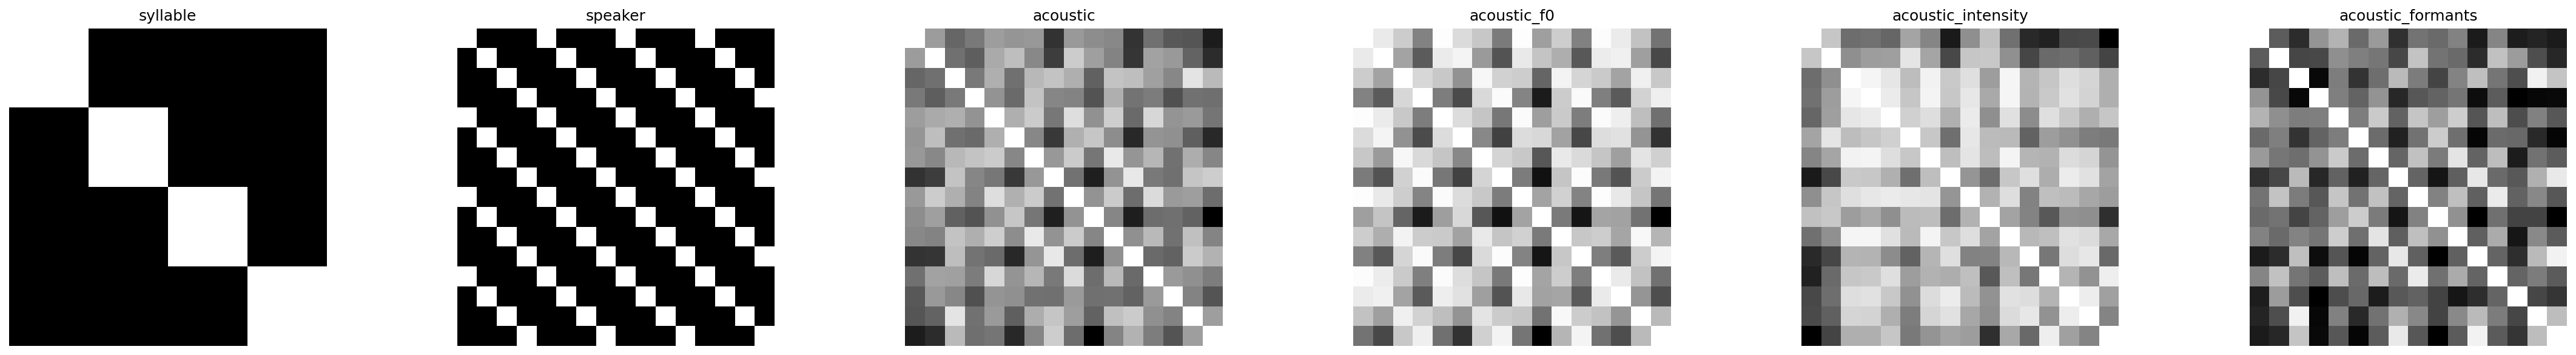

In [7]:
fig, axes = plt.subplots(1, len(model_rdms), figsize=(5 * len(model_rdms), 4), dpi=150)
if len(model_rdms) == 1:
    axes = [axes]
for ax, (name, mat) in zip(axes, model_rdms.items()):
    sns.heatmap(mat, cmap='Greys', square=True, cbar=False, xticklabels=False, yticklabels=False, ax=ax)
    ax.set_title(name)
fig.tight_layout()

### Per-subject, per-ROI model-fit scalars

In [8]:
def get_roi_rdm_vector(rdms_obj, roi):
    """Extract the single dissimilarity vector for one ROI from a subject's full RDMs object.
    NOTE: .get_vectors() is rsatoolbox's compressed (upper-triangular) vector form -- confirm
    this exact method name on first real run; .get_matrices() is the square-matrix alternative
    if this doesn't match the installed rsatoolbox version.
    """
    roi_rdm = rdms_obj.subset('ROI', roi)
    return roi_rdm.get_vectors()[0]


model_fit_rows = []
for sub_id, rdms_obj in subject_rdms.items():
    group = 'CWNS' if sub_id in sub_list_cwns else 'CWS'
    for roi in CORTICAL_ROI_LIST:
        try:
            roi_rdm = rdms_obj.subset('ROI', roi)
        except Exception as e:
            print(f'Could not extract ROI {roi} for {sub_id}: {e}')
            continue

        for model_name, model_mat in model_rdms.items():
            model_rdm_obj = rsatoolbox.rdm.RDMs(
                model_mat[np.newaxis, :, :],
                rdm_descriptors={'model': [model_name]},
                dissimilarity_measure='Euclidean',
            )
            # NOTE: rsatoolbox.rdm.compare()'s exact signature/return shape (scalar vs. 1x1
            # array) is not independently confirmed against an installed version -- adjust the
            # indexing below if this doesn't match on first real run.
            fit = rsatoolbox.rdm.compare(roi_rdm, model_rdm_obj, method='corr')
            fit_value = np.asarray(fit).flatten()[0]

            model_fit_rows.append({
                'subject_id': sub_id, 'group': group, 'ROI': roi,
                'model': model_name, 'fit': fit_value,
            })

model_fit_df = pd.DataFrame(model_fit_rows)
model_fit_df.to_csv(os.path.join(out_dir, f'model_fit_scalars_noiselevel-{NOISE_LEVEL_TAG}.csv'), index=False)
model_fit_df.head()

,subject_id,group,ROI,model,fit
0,sub-SSP008,CWNS,L-HG,syllable,0.041095
1,sub-SSP008,CWNS,L-HG,speaker,-0.013822
2,sub-SSP008,CWNS,L-HG,acoustic,-0.008783
3,sub-SSP008,CWNS,L-HG,acoustic_f0,0.001653
4,sub-SSP008,CWNS,L-HG,acoustic_intensity,-0.069512


### Noise ceiling (per ROI, per group)

Estimates the best model-fit correlation achievable in each ROI given the noise in the empirical
data itself, independent of any model (Nili et al. 2014). Computed **per ROI x per group**
(CWS and CWNS separately) since they have very different sample sizes (CWS n=7 vs. CWNS n=23) and
thus different achievable ceilings -- expect CWS's ceiling to be wider/noisier than CWNS's; that
is expected, not a bug. Directly contextualizes the model-fit values above: e.g. whether a
correlation of ~0.06 in some ROI is a large or small fraction of what is achievable there.

In [ ]:
def compute_noise_ceiling(rdm_vectors):
    """Upper/lower noise-ceiling bounds (Nili et al. 2014) for one ROI's RDM vectors across a
    set of subjects (same group). Upper bound: each subject's vector correlated (Pearson, same
    method='corr' semantics used for model-fit) against the mean of ALL subjects' vectors
    (including their own) -- optimistic, since a subject's own data leaks into the reference
    it's compared against. Lower bound: each subject's vector correlated against the
    leave-one-out mean of everyone else -- an unbiased estimate of the best fit a genuinely
    novel model could achieve. Both averaged across subjects.
    """
    rdm_vectors = np.vstack(rdm_vectors)
    n = rdm_vectors.shape[0]
    mean_all = rdm_vectors.mean(axis=0)
    upper_corrs = [np.corrcoef(rdm_vectors[i], mean_all)[0, 1] for i in range(n)]

    lower_corrs = []
    for i in range(n):
        mean_loo = np.delete(rdm_vectors, i, axis=0).mean(axis=0)
        lower_corrs.append(np.corrcoef(rdm_vectors[i], mean_loo)[0, 1])

    return {'ceiling_upper': np.mean(upper_corrs), 'ceiling_lower': np.mean(lower_corrs)}


noise_ceiling_rows = []
for roi in CORTICAL_ROI_LIST:
    for group_name, sub_list in [('CWS', sub_list_cws), ('CWNS', sub_list_cwns)]:
        rdm_vectors = [get_roi_rdm_vector(subject_rdms[s], roi) for s in sub_list if s in subject_rdms]
        if len(rdm_vectors) < 3:  # leave-one-out needs >=3 to be meaningful, not just >=2
            print(f'Skipping noise ceiling for {roi}/{group_name}: fewer than 3 subjects ({len(rdm_vectors)})')
            continue
        noise_ceiling_rows.append({
            'ROI': roi, 'group': group_name, 'n': len(rdm_vectors),
            **compute_noise_ceiling(rdm_vectors),
        })

noise_ceiling_df = pd.DataFrame(noise_ceiling_rows)
noise_ceiling_df.to_csv(os.path.join(out_dir, f'noise_ceiling_noiselevel-{NOISE_LEVEL_TAG}.csv'), index=False)
noise_ceiling_df.head()


### Group comparison: subject-level bootstrap

In [9]:
def bootstrap_group_difference(values_a, values_b, n_boot=N_BOOT, rng=RNG):
    """Subject-level bootstrap test for a difference in means between two groups. Resamples
    subjects WITH replacement WITHIN each group (not across groups), computes the group-mean
    difference (a - b) each iteration, and derives a two-sided empirical p-value from how often
    the null-centered bootstrap distribution is at least as extreme as the observed difference.
    Operates purely on whatever scalars are passed in -- agnostic to how they were derived,
    including from GLMsingle-based RDMs (confirmed compatible per the earlier discussion: the
    bootstrap is downstream of and independent from how the single-trial patterns were estimated).
    """
    values_a = np.asarray(values_a)
    values_b = np.asarray(values_b)
    observed_diff = values_a.mean() - values_b.mean()

    boot_diffs = np.empty(n_boot)
    for i in range(n_boot):
        resampled_a = rng.choice(values_a, size=len(values_a), replace=True)
        resampled_b = rng.choice(values_b, size=len(values_b), replace=True)
        boot_diffs[i] = resampled_a.mean() - resampled_b.mean()

    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
    null_centered = boot_diffs - boot_diffs.mean()
    p_value = np.mean(np.abs(null_centered) >= np.abs(observed_diff))

    return {'observed_diff': observed_diff, 'ci_low': ci_low, 'ci_high': ci_high, 'p_value': p_value}


group_comparison_rows = []
for roi in CORTICAL_ROI_LIST:
    for model_name in model_rdms.keys():
        subset = model_fit_df[(model_fit_df.ROI == roi) & (model_fit_df.model == model_name)]
        cws_vals = subset.loc[subset.group == 'CWS', 'fit'].values
        cwns_vals = subset.loc[subset.group == 'CWNS', 'fit'].values
        if len(cws_vals) < 2 or len(cwns_vals) < 2:
            print(f'Skipping {roi}/{model_name}: not enough subjects per group')
            continue

        result = bootstrap_group_difference(cws_vals, cwns_vals)
        group_comparison_rows.append({
            'ROI': roi, 'model': model_name,
            'n_cws': len(cws_vals), 'n_cwns': len(cwns_vals),
            **result,
        })

group_comparison_df = pd.DataFrame(group_comparison_rows)
# FDR correction across every ROI x model test in this table (one global correction, not
# scoped per-ROI or per-model) -- the raw, uncorrected p_value column is kept alongside it.
group_comparison_df['p_fdr'] = multipletests(group_comparison_df['p_value'], method='fdr_bh')[1]
group_comparison_df.to_csv(os.path.join(out_dir, f'group_comparison_bootstrap_noiselevel-{NOISE_LEVEL_TAG}.csv'), index=False)
group_comparison_df.sort_values('p_value').head(20)

,ROI,model,n_cws,n_cwns,observed_diff,ci_low,ci_high,p_value
105,R-SMGa,acoustic_f0,7,23,-0.095284,-0.147039,-0.041398,0.0002
19,L-STGp,speaker,7,23,0.067888,0.023965,0.113043,0.0014
59,L-Ang,acoustic_formants,7,23,-0.103493,-0.169244,-0.038987,0.0018
36,L-ParsTri,syllable,7,23,0.058336,0.011545,0.105458,0.0139
47,L-SMGa,acoustic_formants,7,23,-0.085869,-0.160433,-0.006750,0.0296
56,L-Ang,acoustic,7,23,-0.075151,-0.146461,-0.007078,0.0349
37,L-ParsTri,speaker,7,23,-0.045145,-0.088069,-0.002657,0.0376
119,R-Ang,acoustic_formants,7,23,-0.084770,-0.165823,-0.003241,0.0405
53,L-SMGp,acoustic_formants,7,23,-0.107980,-0.227407,-0.003368,0.0596
50,L-SMGp,acoustic,7,23,-0.108401,-0.226241,0.001318,0.0637


### Within-group significance testing (which ROIs are significant for which models?)

In addition to the between-group comparison above, test **within each group separately**: is the mean model-fit significantly different from 0 (i.e. is this categorical distinction actually represented in this ROI, for this group)? Same subject-level bootstrap philosophy, applied as a one-sample test instead of a two-sample difference test. Same "independent per-ROI/model, uncorrected" multiple-comparisons stance as the between-group test.

In [10]:
def bootstrap_one_sample(values, null_value=0, n_boot=N_BOOT, rng=RNG):
    """Subject-level bootstrap one-sample test: is the mean of `values` significantly
    different from `null_value` (typically 0, i.e. no representational correlation with the
    model)? Resamples subjects with replacement within a single group, builds an empirical
    distribution of the mean, and derives a two-sided p-value/CI for whether the observed mean
    differs from null_value.
    """
    values = np.asarray(values)
    observed_mean = values.mean()

    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        resampled = rng.choice(values, size=len(values), replace=True)
        boot_means[i] = resampled.mean()

    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    # center the bootstrap distribution at null_value (removing its own sampling bias first) to
    # test how extreme the observed mean is under a null of "no effect"
    null_centered = boot_means - boot_means.mean() + null_value
    p_value = np.mean(np.abs(null_centered - null_value) >= np.abs(observed_mean - null_value))

    return {'observed_mean': observed_mean, 'ci_low': ci_low, 'ci_high': ci_high, 'p_value': p_value}


within_group_rows = []
for roi in CORTICAL_ROI_LIST:
    for model_name in model_rdms.keys():
        subset = model_fit_df[(model_fit_df.ROI == roi) & (model_fit_df.model == model_name)]
        for group_name in ['CWS', 'CWNS']:
            vals = subset.loc[subset.group == group_name, 'fit'].values
            if len(vals) < 2:
                print(f'Skipping {roi}/{model_name}/{group_name}: not enough subjects')
                continue

            result = bootstrap_one_sample(vals)
            within_group_rows.append({
                'ROI': roi, 'model': model_name, 'group': group_name, 'n': len(vals),
                **result,
            })

within_group_significance_df = pd.DataFrame(within_group_rows)
# FDR correction across every ROI x model x group test in this table (one global correction).
within_group_significance_df['p_fdr'] = multipletests(within_group_significance_df['p_value'], method='fdr_bh')[1]
within_group_significance_df.to_csv(
    os.path.join(out_dir, f'within_group_significance_noiselevel-{NOISE_LEVEL_TAG}.csv'), index=False)
within_group_significance_df.sort_values('p_value').head(20)

,ROI,model,group,n,observed_mean,ci_low,ci_high,p_value
170,R-STGa,speaker,CWS,7,0.028828,0.014252,0.043054,0.0000
122,R-HG,speaker,CWS,7,-0.033978,-0.050118,-0.018268,0.0000
37,L-STGp,syllable,CWNS,23,0.044685,0.023487,0.066760,0.0000
210,R-SMGa,acoustic_f0,CWS,7,-0.068833,-0.105010,-0.027848,0.0007
174,R-STGa,acoustic_f0,CWS,7,0.064202,0.021493,0.111017,0.0046
66,L-ParsOp,acoustic_f0,CWS,7,-0.072122,-0.121714,-0.018779,0.0047
104,L-SMGp,acoustic_intensity,CWS,7,-0.074262,-0.130148,-0.014254,0.0073
115,L-Ang,acoustic_f0,CWNS,23,0.055774,0.011884,0.095878,0.0095
39,L-STGp,speaker,CWNS,23,-0.023725,-0.042139,-0.005052,0.0111
166,R-STGp,acoustic_formants,CWS,7,-0.068197,-0.115537,-0.011861,0.0115


### Direct RDM comparison (descriptive complement)

In [11]:
def bootstrap_rdm_distance(rdm_vectors_a, rdm_vectors_b, n_boot=N_BOOT, rng=RNG):
    """Bootstrap CI for whether two groups' mean RDMs differ, using 1 - Pearson correlation
    between the two group-mean RDM vectors as the dissimilarity-of-dissimilarities statistic.
    Descriptive complement to the categorical-model-fit comparison above -- no categorical
    models involved, just "is the overall similarity structure different between groups."
    Doesn't have a natural null-hypothesis p-value the way a mean-difference bootstrap does;
    report the CI and whether it's close to 0 (little difference) or not.
    """
    rdm_vectors_a = np.vstack(rdm_vectors_a)
    rdm_vectors_b = np.vstack(rdm_vectors_b)

    def rdm_corr_distance(vecs_a, vecs_b):
        mean_a = vecs_a.mean(axis=0)
        mean_b = vecs_b.mean(axis=0)
        r = np.corrcoef(mean_a, mean_b)[0, 1]
        return 1 - r

    observed_distance = rdm_corr_distance(rdm_vectors_a, rdm_vectors_b)

    idx_a = np.arange(len(rdm_vectors_a))
    idx_b = np.arange(len(rdm_vectors_b))
    boot_distances = np.empty(n_boot)
    for i in range(n_boot):
        resampled_a = rdm_vectors_a[rng.choice(idx_a, size=len(idx_a), replace=True)]
        resampled_b = rdm_vectors_b[rng.choice(idx_b, size=len(idx_b), replace=True)]
        boot_distances[i] = rdm_corr_distance(resampled_a, resampled_b)

    ci_low, ci_high = np.percentile(boot_distances, [2.5, 97.5])
    return {'observed_distance': observed_distance, 'ci_low': ci_low, 'ci_high': ci_high}


mean_rdm_rows = []
for roi in CORTICAL_ROI_LIST:
    cws_vectors = [get_roi_rdm_vector(subject_rdms[s], roi) for s in sub_list_cws if s in subject_rdms]
    cwns_vectors = [get_roi_rdm_vector(subject_rdms[s], roi) for s in sub_list_cwns if s in subject_rdms]
    if len(cws_vectors) < 2 or len(cwns_vectors) < 2:
        continue

    result = bootstrap_rdm_distance(cws_vectors, cwns_vectors)
    mean_rdm_rows.append({'ROI': roi, **result})

mean_rdm_df = pd.DataFrame(mean_rdm_rows)
mean_rdm_df.to_csv(os.path.join(out_dir, f'mean_rdm_comparison_noiselevel-{NOISE_LEVEL_TAG}.csv'), index=False)
mean_rdm_df.sort_values('observed_distance', ascending=False)

,ROI,observed_distance,ci_low,ci_high
10,R-HG,1.286254,0.719747,1.317682
9,L-Ang,1.255960,0.657382,1.330869
5,L-ParsOp,1.169789,0.795911,1.258125
8,L-SMGp,1.116029,0.816525,1.375669
6,L-ParsTri,1.114641,0.886522,1.267480
2,L-PP,1.045189,0.866968,1.276224
11,R-PT,1.042575,0.805983,1.337990
15,R-ParsOp,1.031632,0.731546,1.190610
7,L-SMGa,1.018469,0.812005,1.199750
16,R-ParsTri,1.009587,0.767920,1.194625


#### QC: visualize CWS-mean vs. CWNS-mean RDM for one ROI

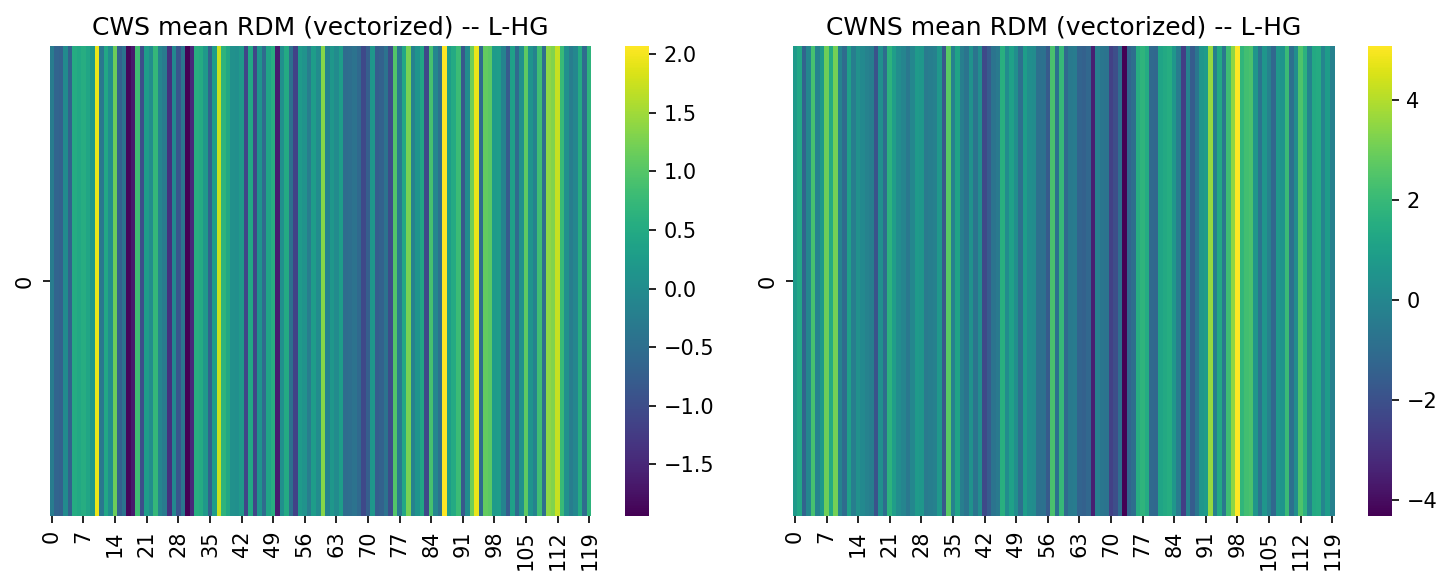

In [12]:
example_roi = CORTICAL_ROI_LIST[0]
cws_vectors = [get_roi_rdm_vector(subject_rdms[s], example_roi) for s in sub_list_cws if s in subject_rdms]
cwns_vectors = [get_roi_rdm_vector(subject_rdms[s], example_roi) for s in sub_list_cwns if s in subject_rdms]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)
sns.heatmap(np.vstack(cws_vectors).mean(axis=0).reshape(1, -1), cmap='viridis', ax=axes[0], cbar=True)
axes[0].set_title(f'CWS mean RDM (vectorized) -- {example_roi}')
sns.heatmap(np.vstack(cwns_vectors).mean(axis=0).reshape(1, -1), cmap='viridis', ax=axes[1], cbar=True)
axes[1].set_title(f'CWNS mean RDM (vectorized) -- {example_roi}')
fig.tight_layout()

### Boxplot + stripplot per model

Mirrors `fMRI_auditory-category-learning/06_univariate/group_level_all_ROI.ipynb`'s
`plot_roi_box_plots` pattern: stripplot + boxplot overlay, both with fill stripped to
transparent and outlined in each hue group's assigned color instead (not a default/neutral
outline). ROIs with a significant within-group effect (p < 0.05, from the bootstrap one-sample
test above) get an asterisk above them, with headroom added so it doesn't collide with the title.

Two variants:
1. **Combined** (`x=ROI` for all 20 ROIs, `hue=group`) -- one figure per model. Asterisk marks a
   ROI if *either* group is significant there (not group-specific).
2. **Group-specific** (`x=region` -- base ROI name, hemisphere prefix stripped -- `hue=hemisphere`)
   -- one figure per (model, group), fewer x-categories (10 base regions instead of 20 ROIs).
   Asterisks are placed over the specific L or R box (using seaborn's dodge offset), so
   significance is shown per-hemisphere, not pooled across both.

/scratch/slurm-10624839/ipykernel_3977115/2347574291.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/scratch/slurm-10624839/ipykernel_3977115/2347574291.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/scratch/slurm-10624839/ipykernel_3977115/2347574291.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/scratch/slurm-10624839/ipykernel_3977115/2347574291.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),

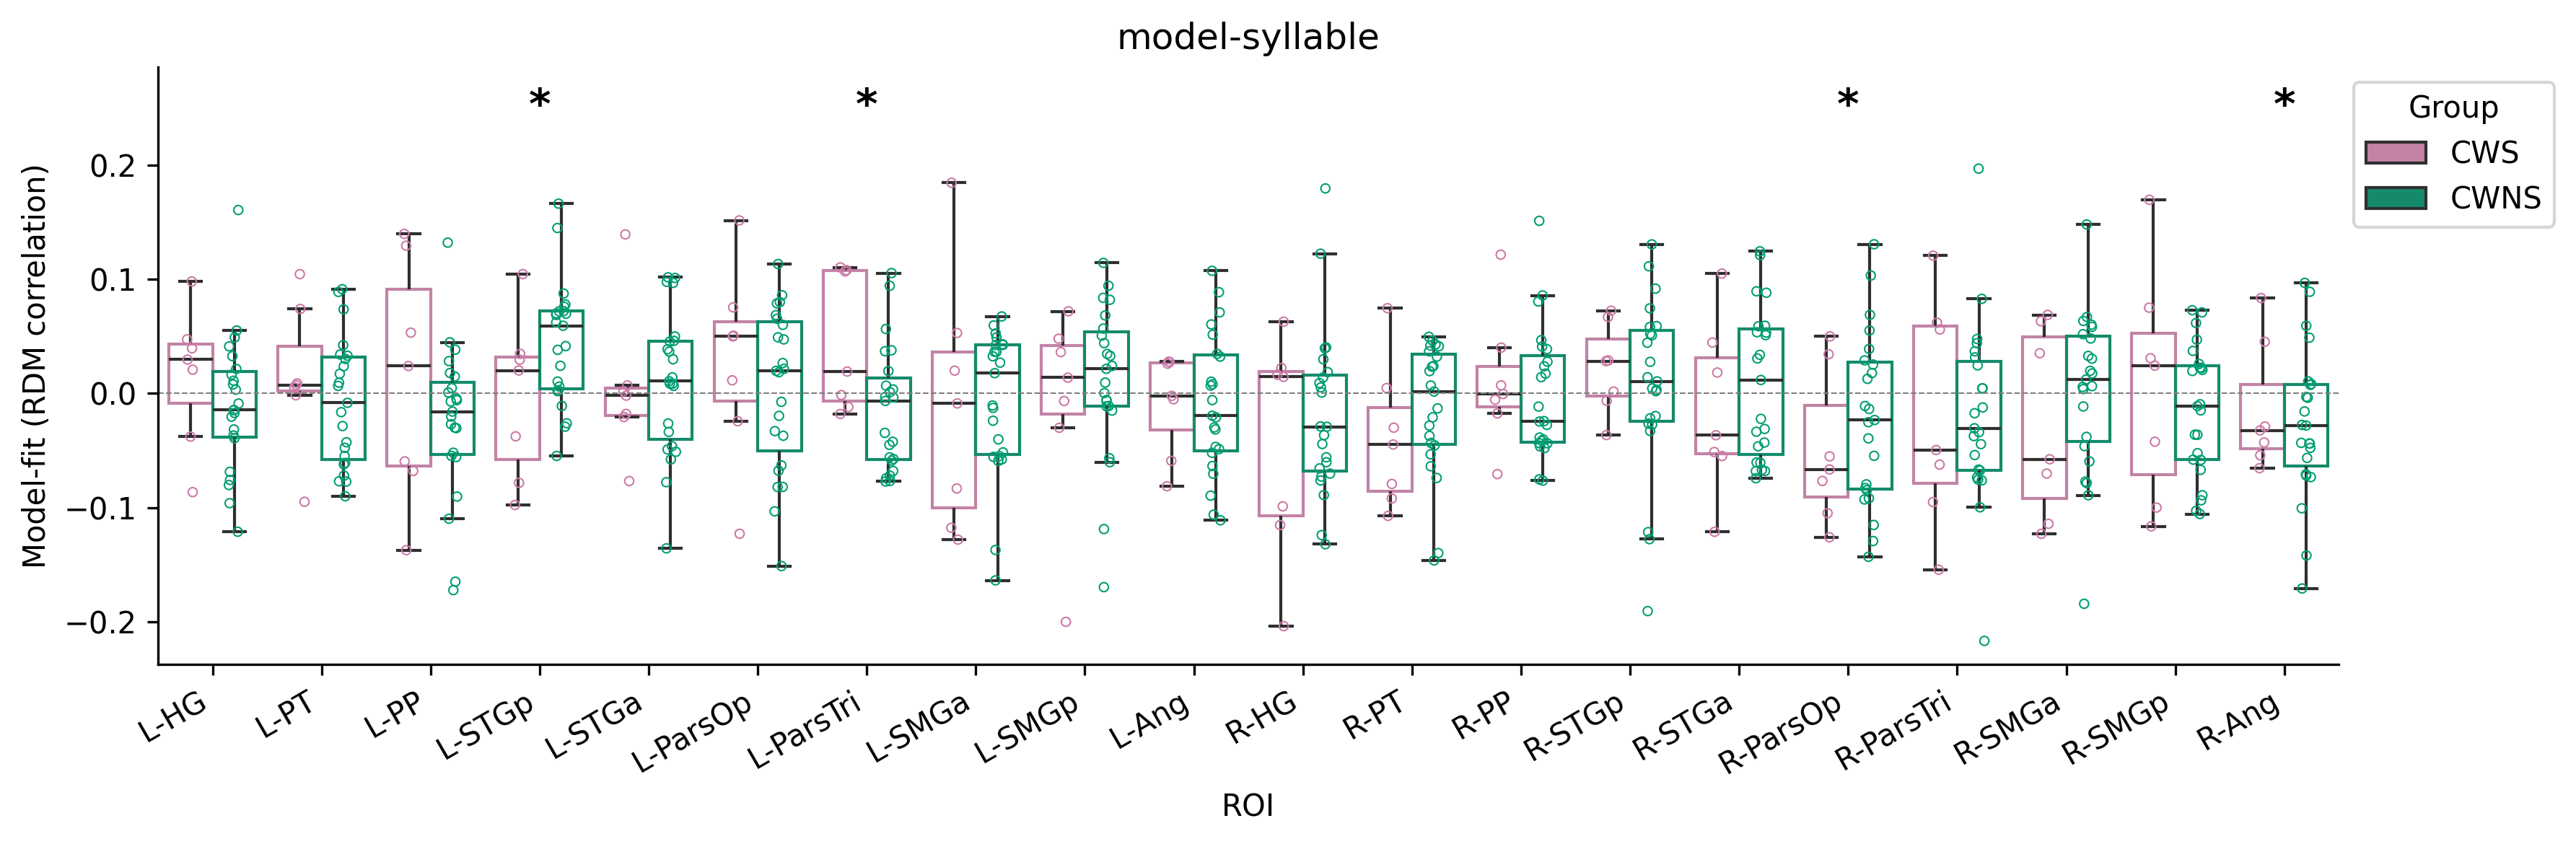

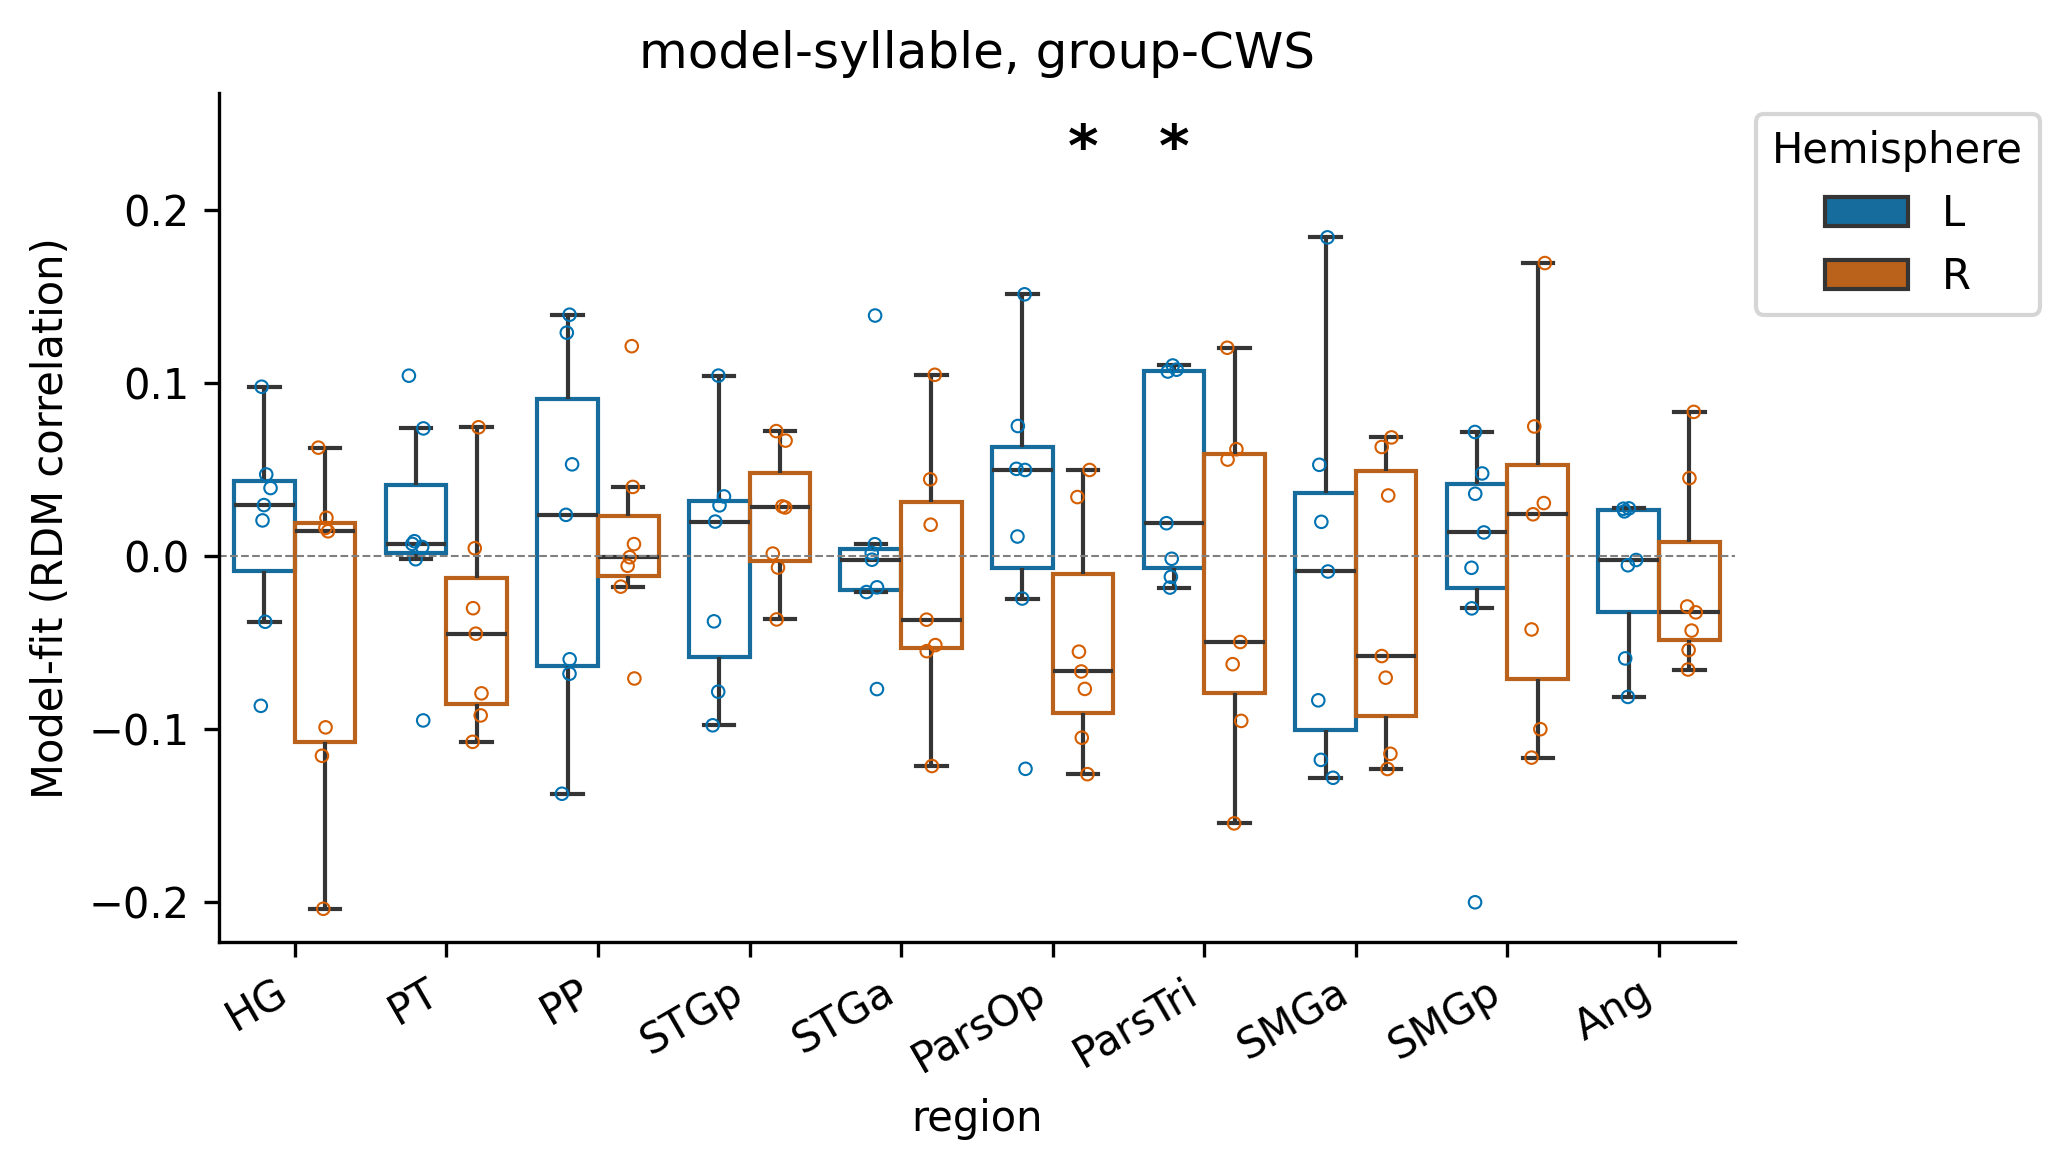

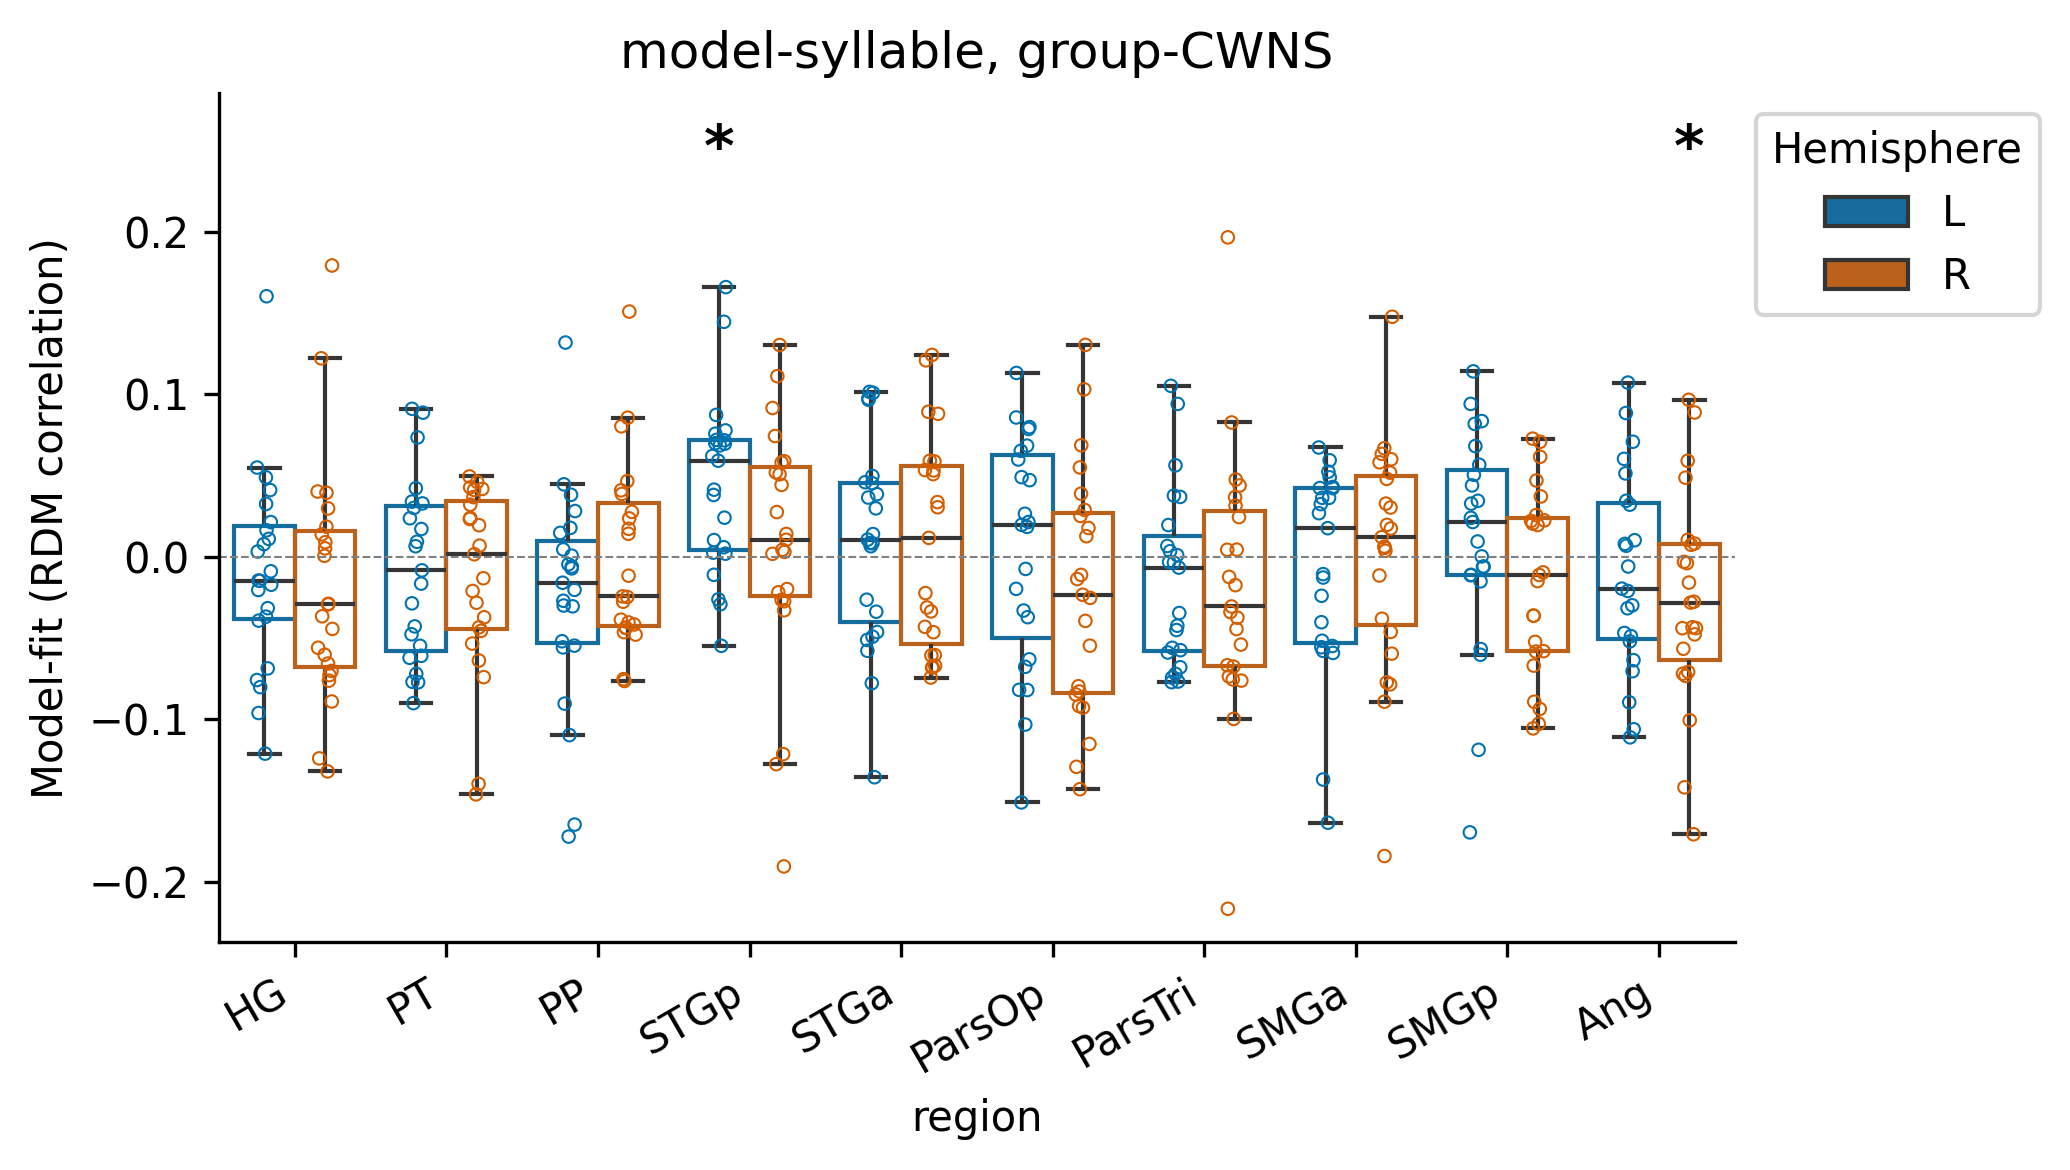

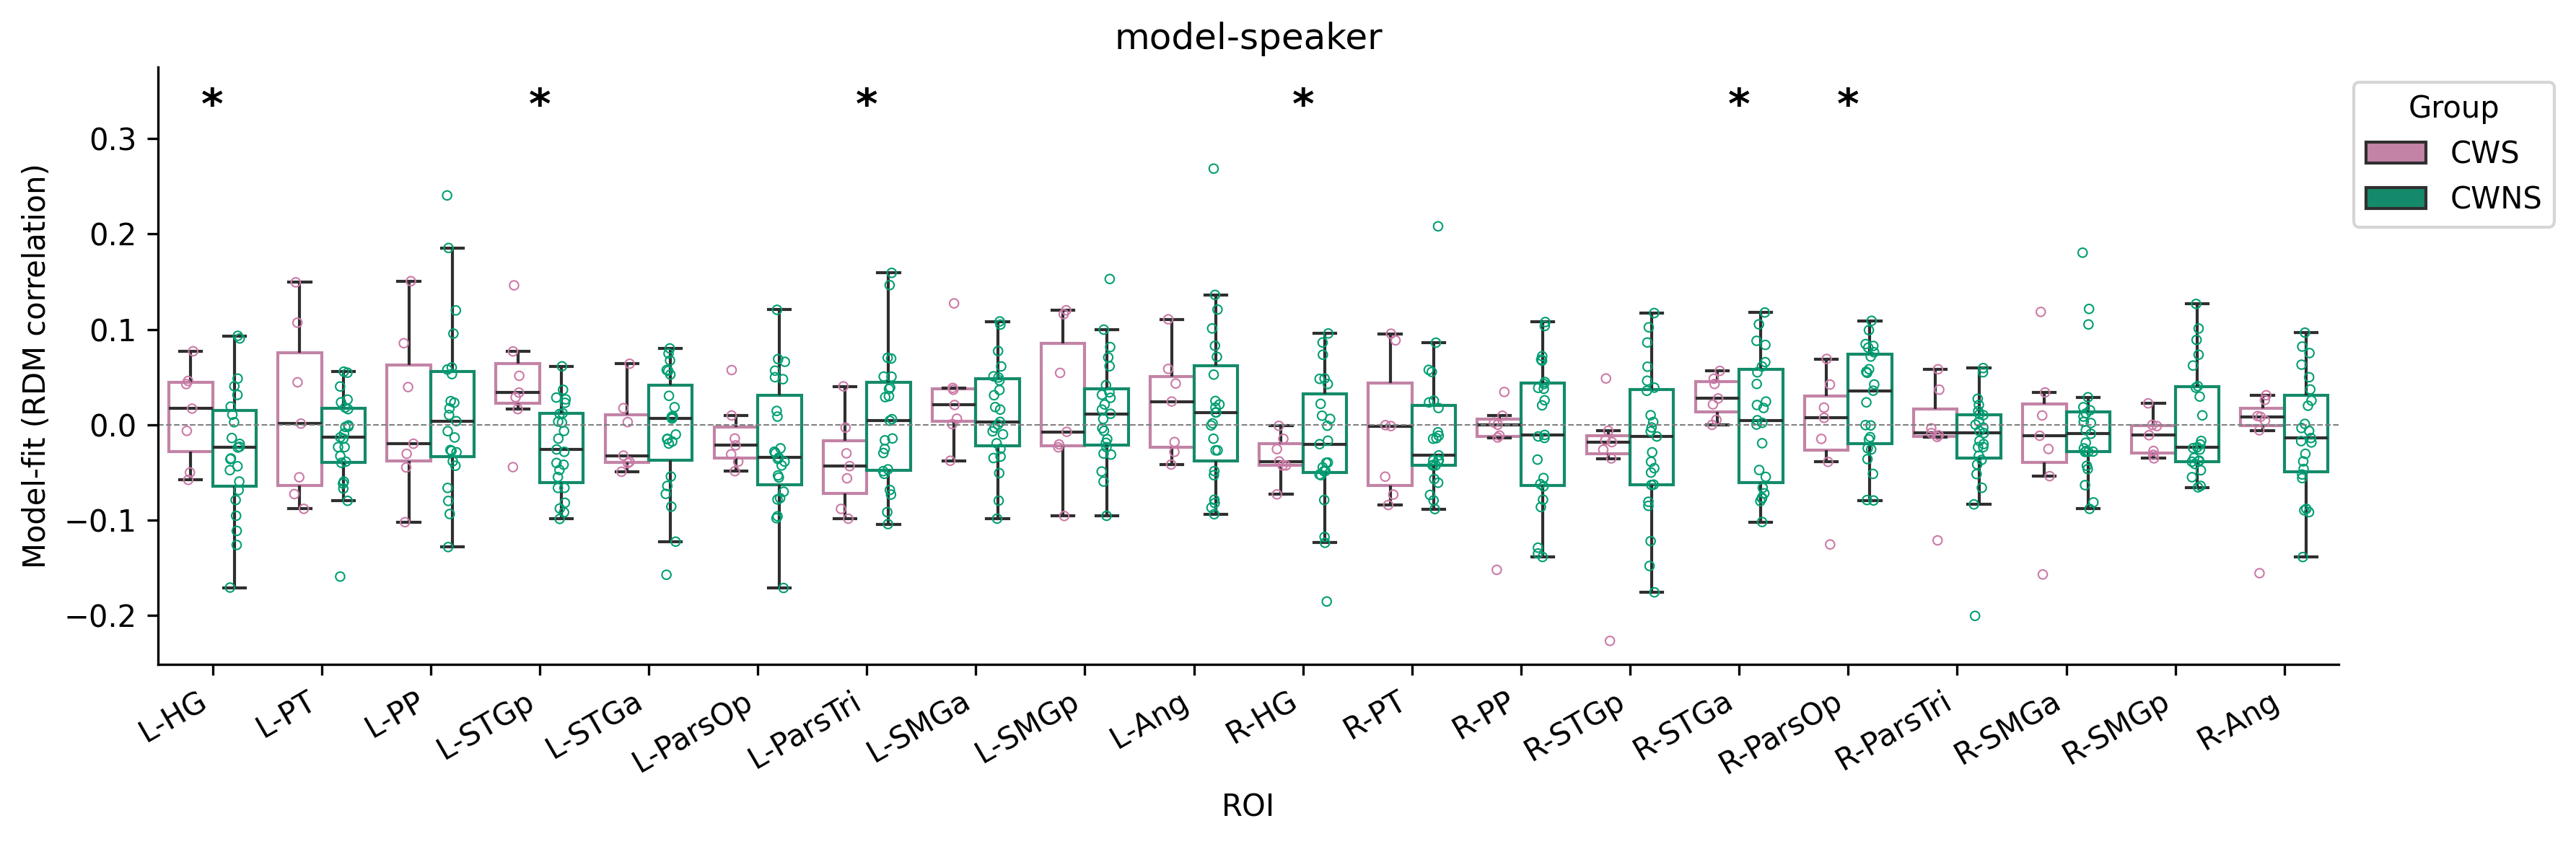

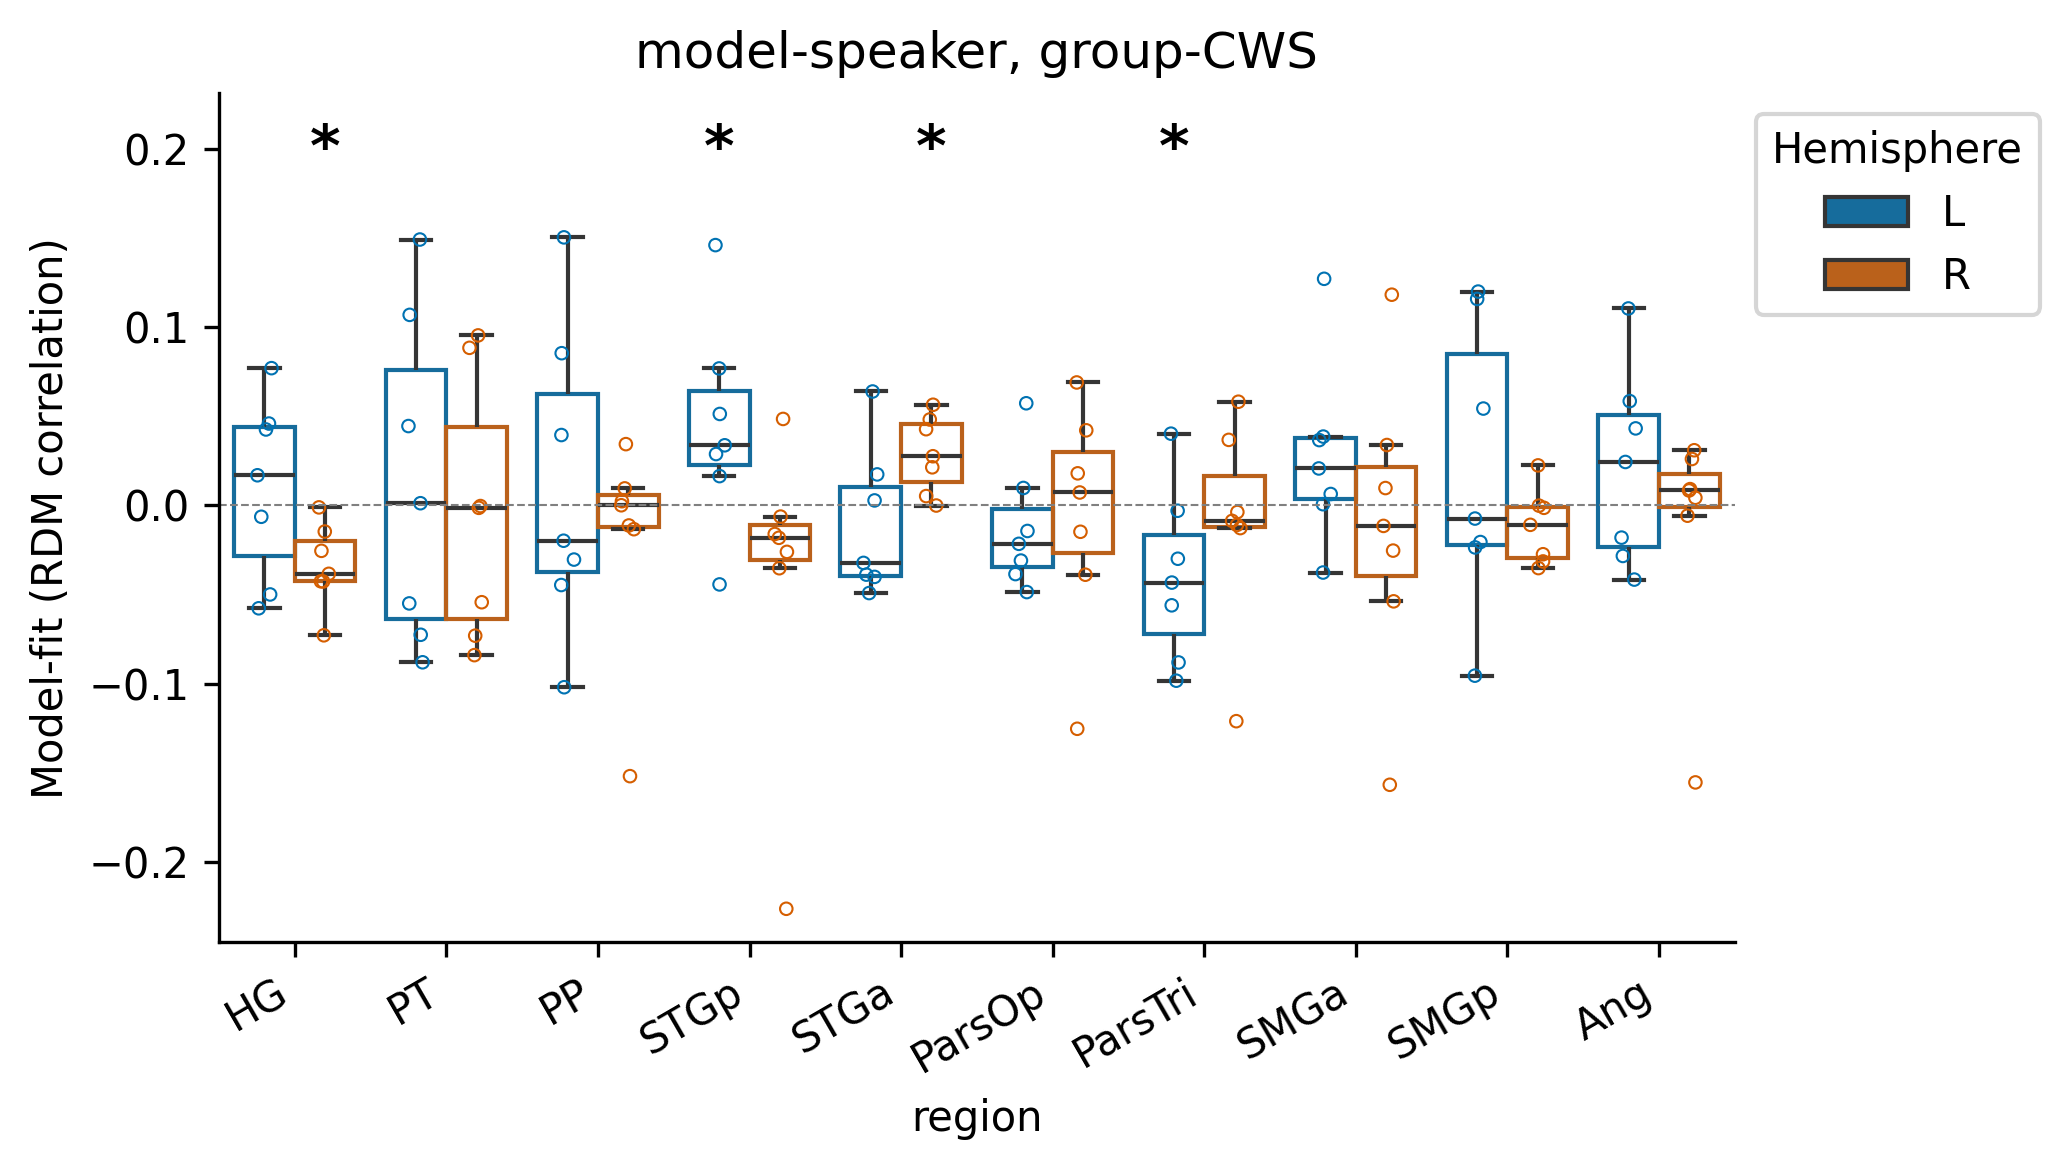

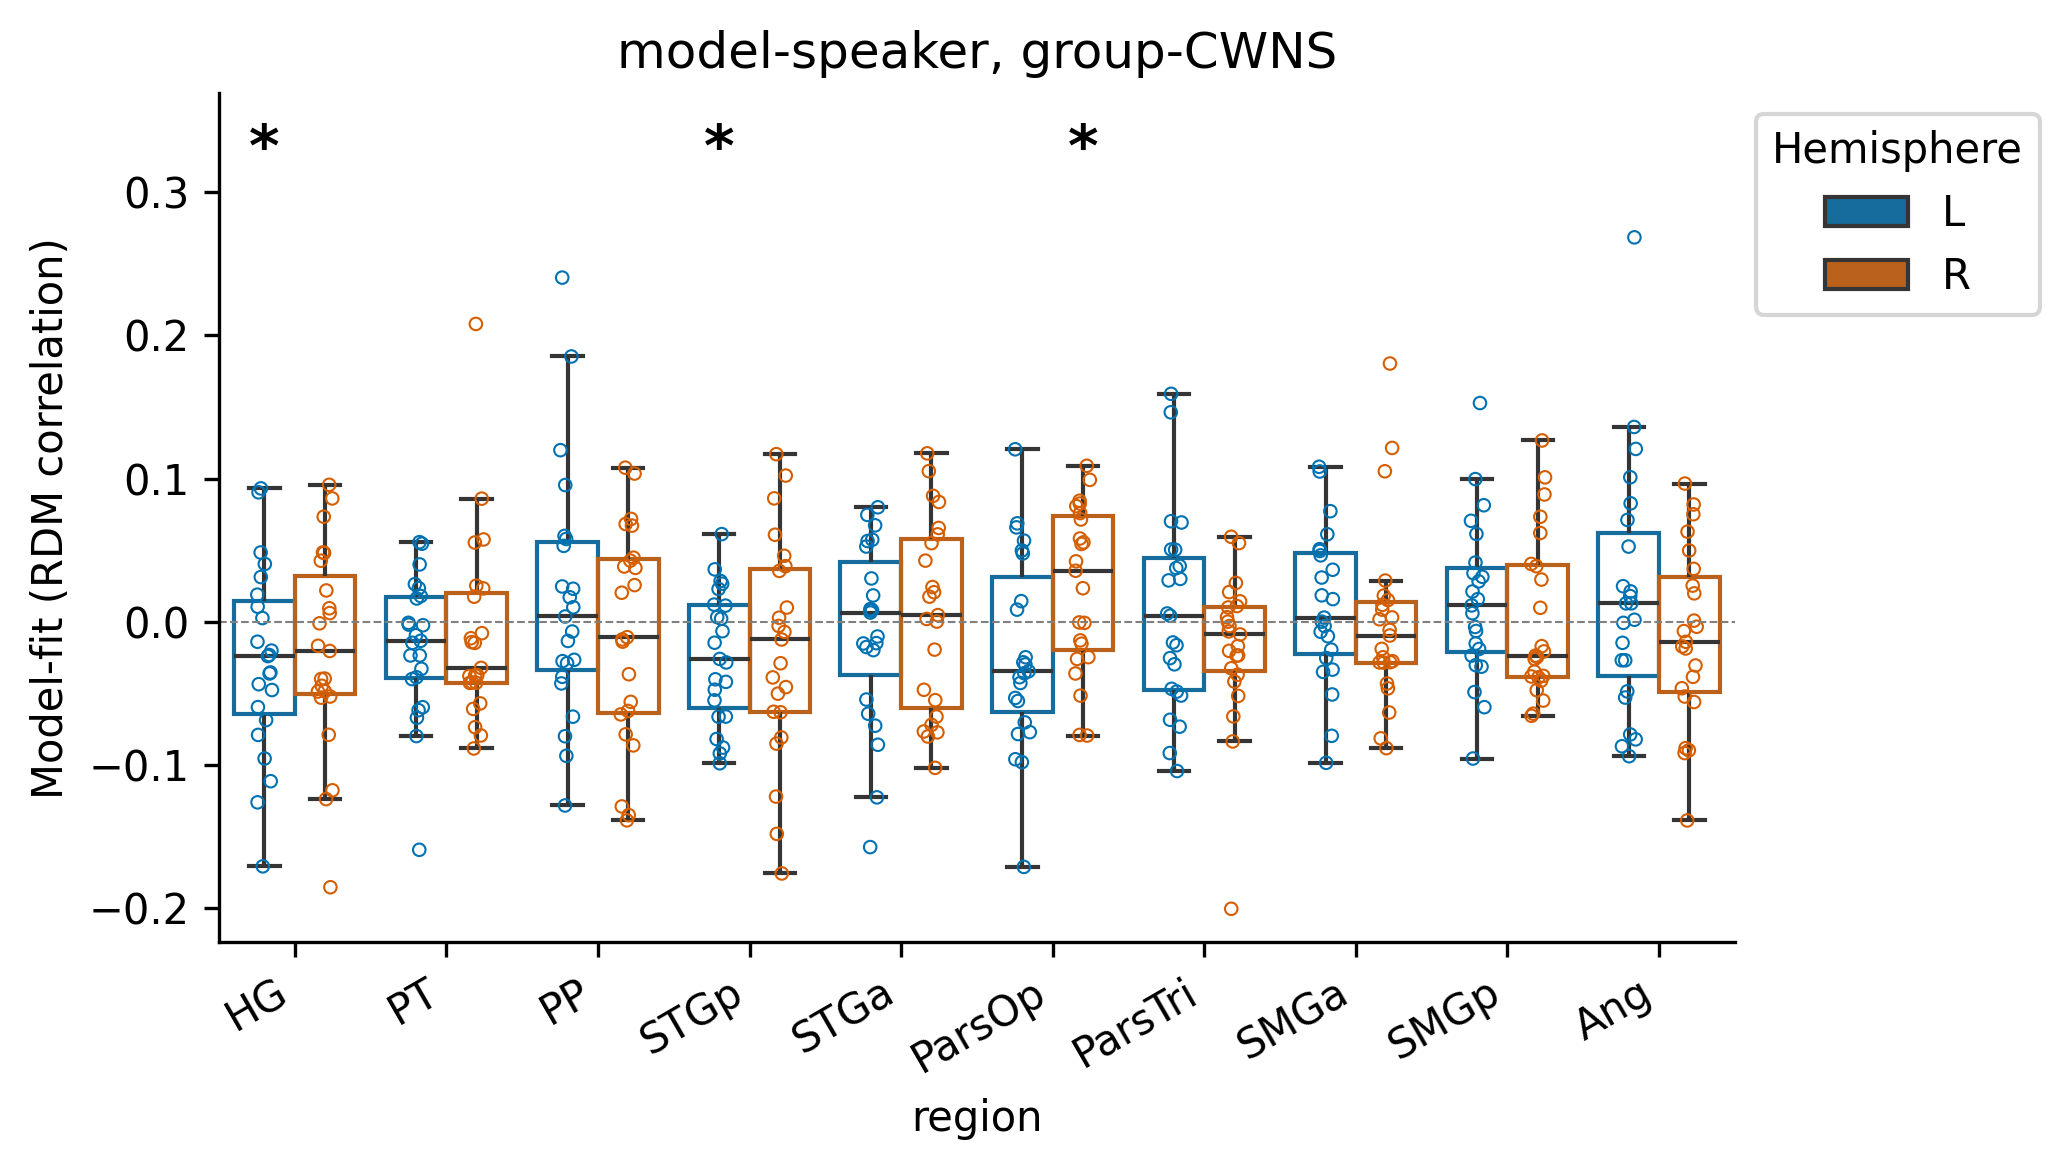

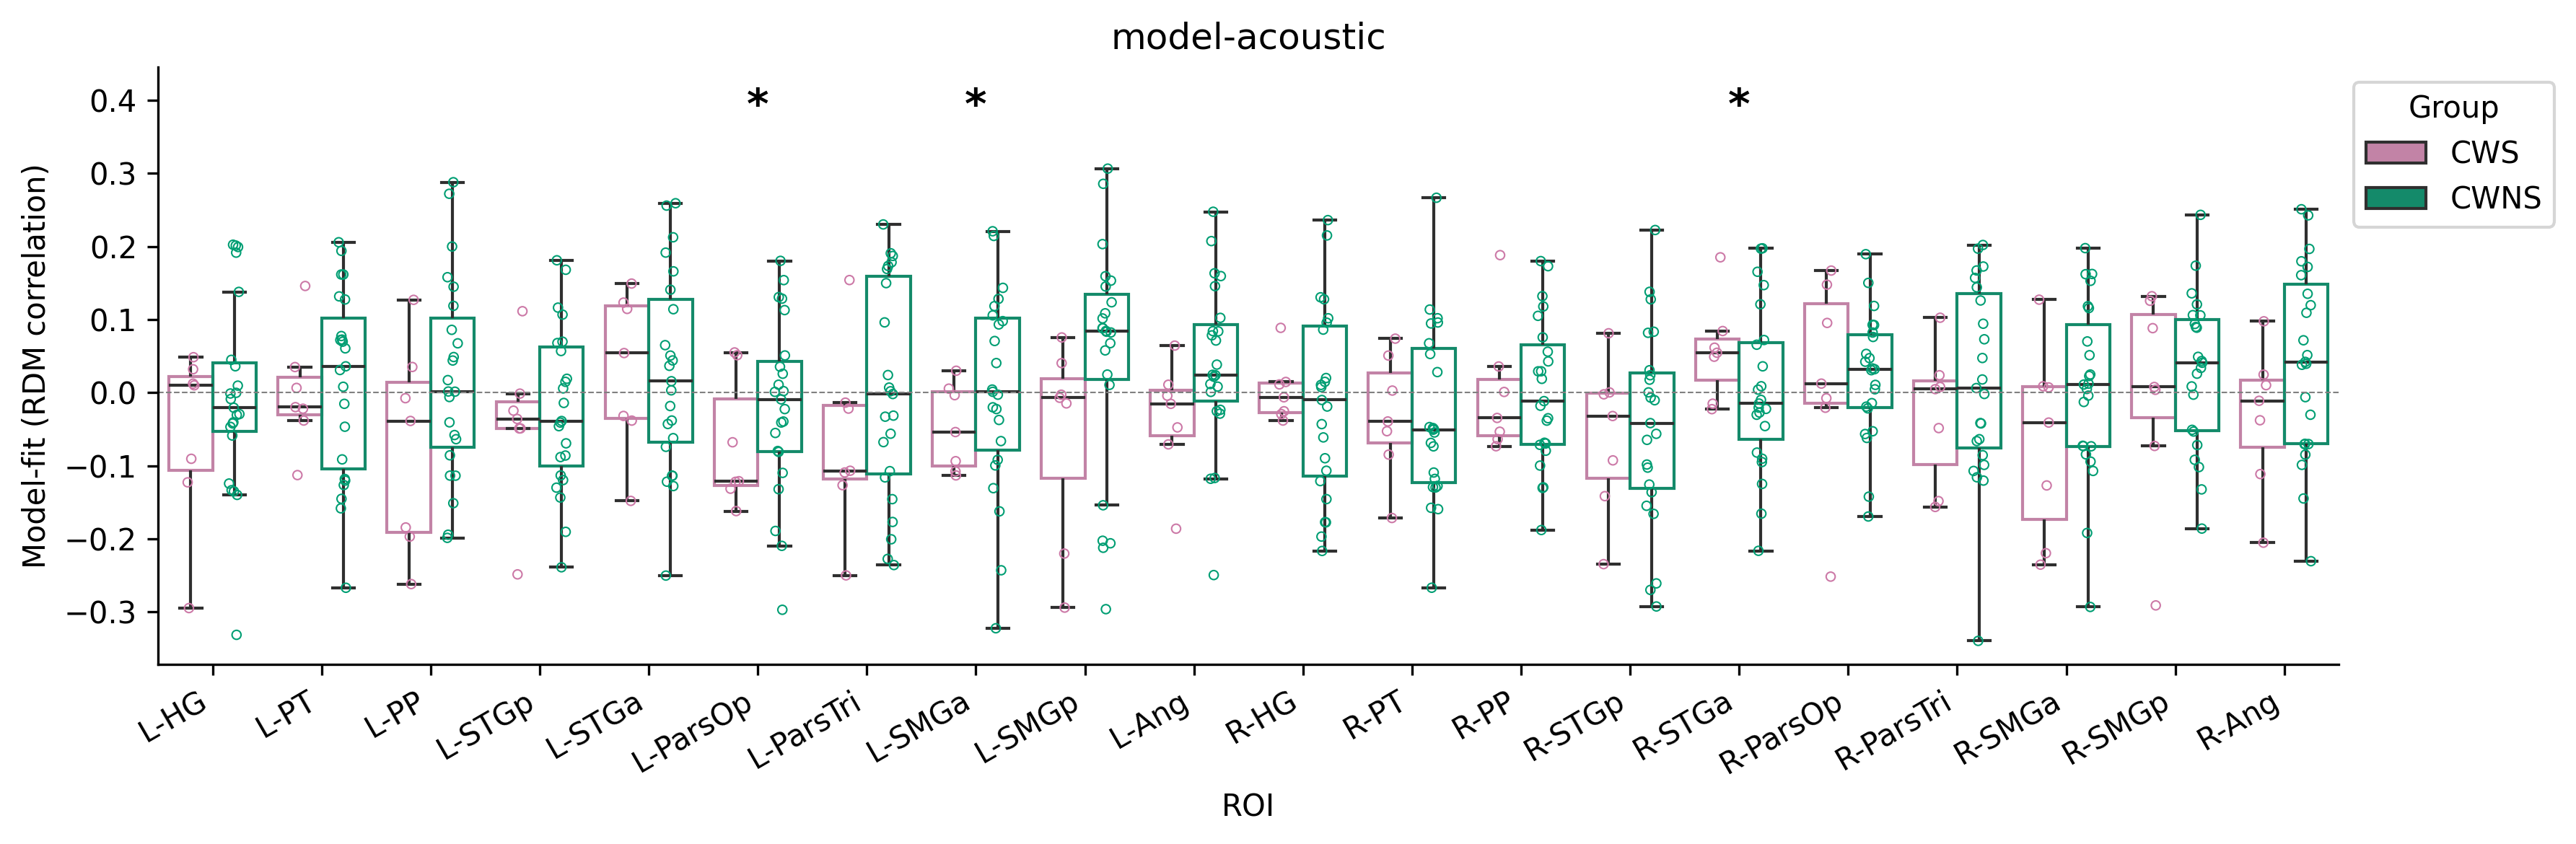

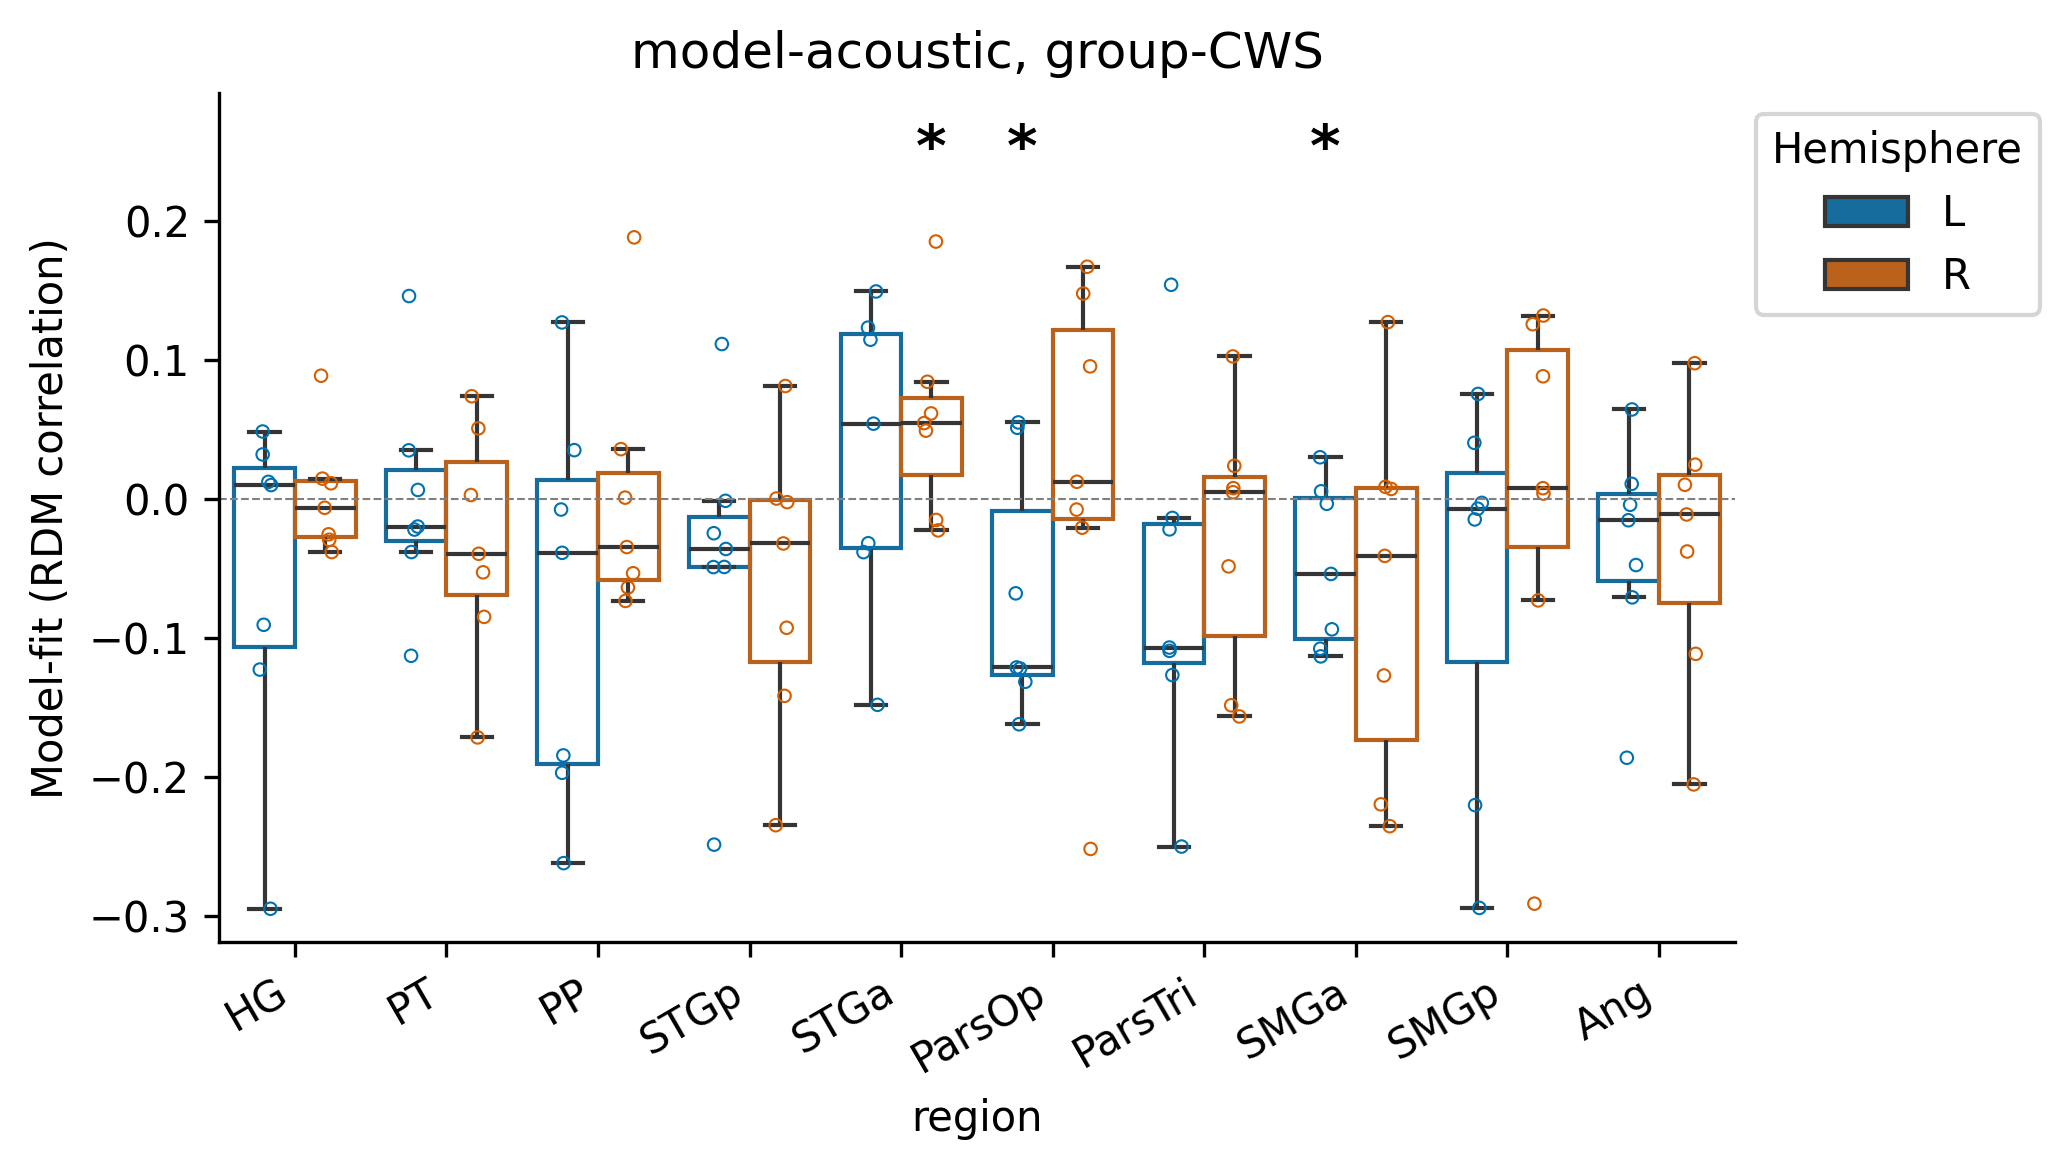

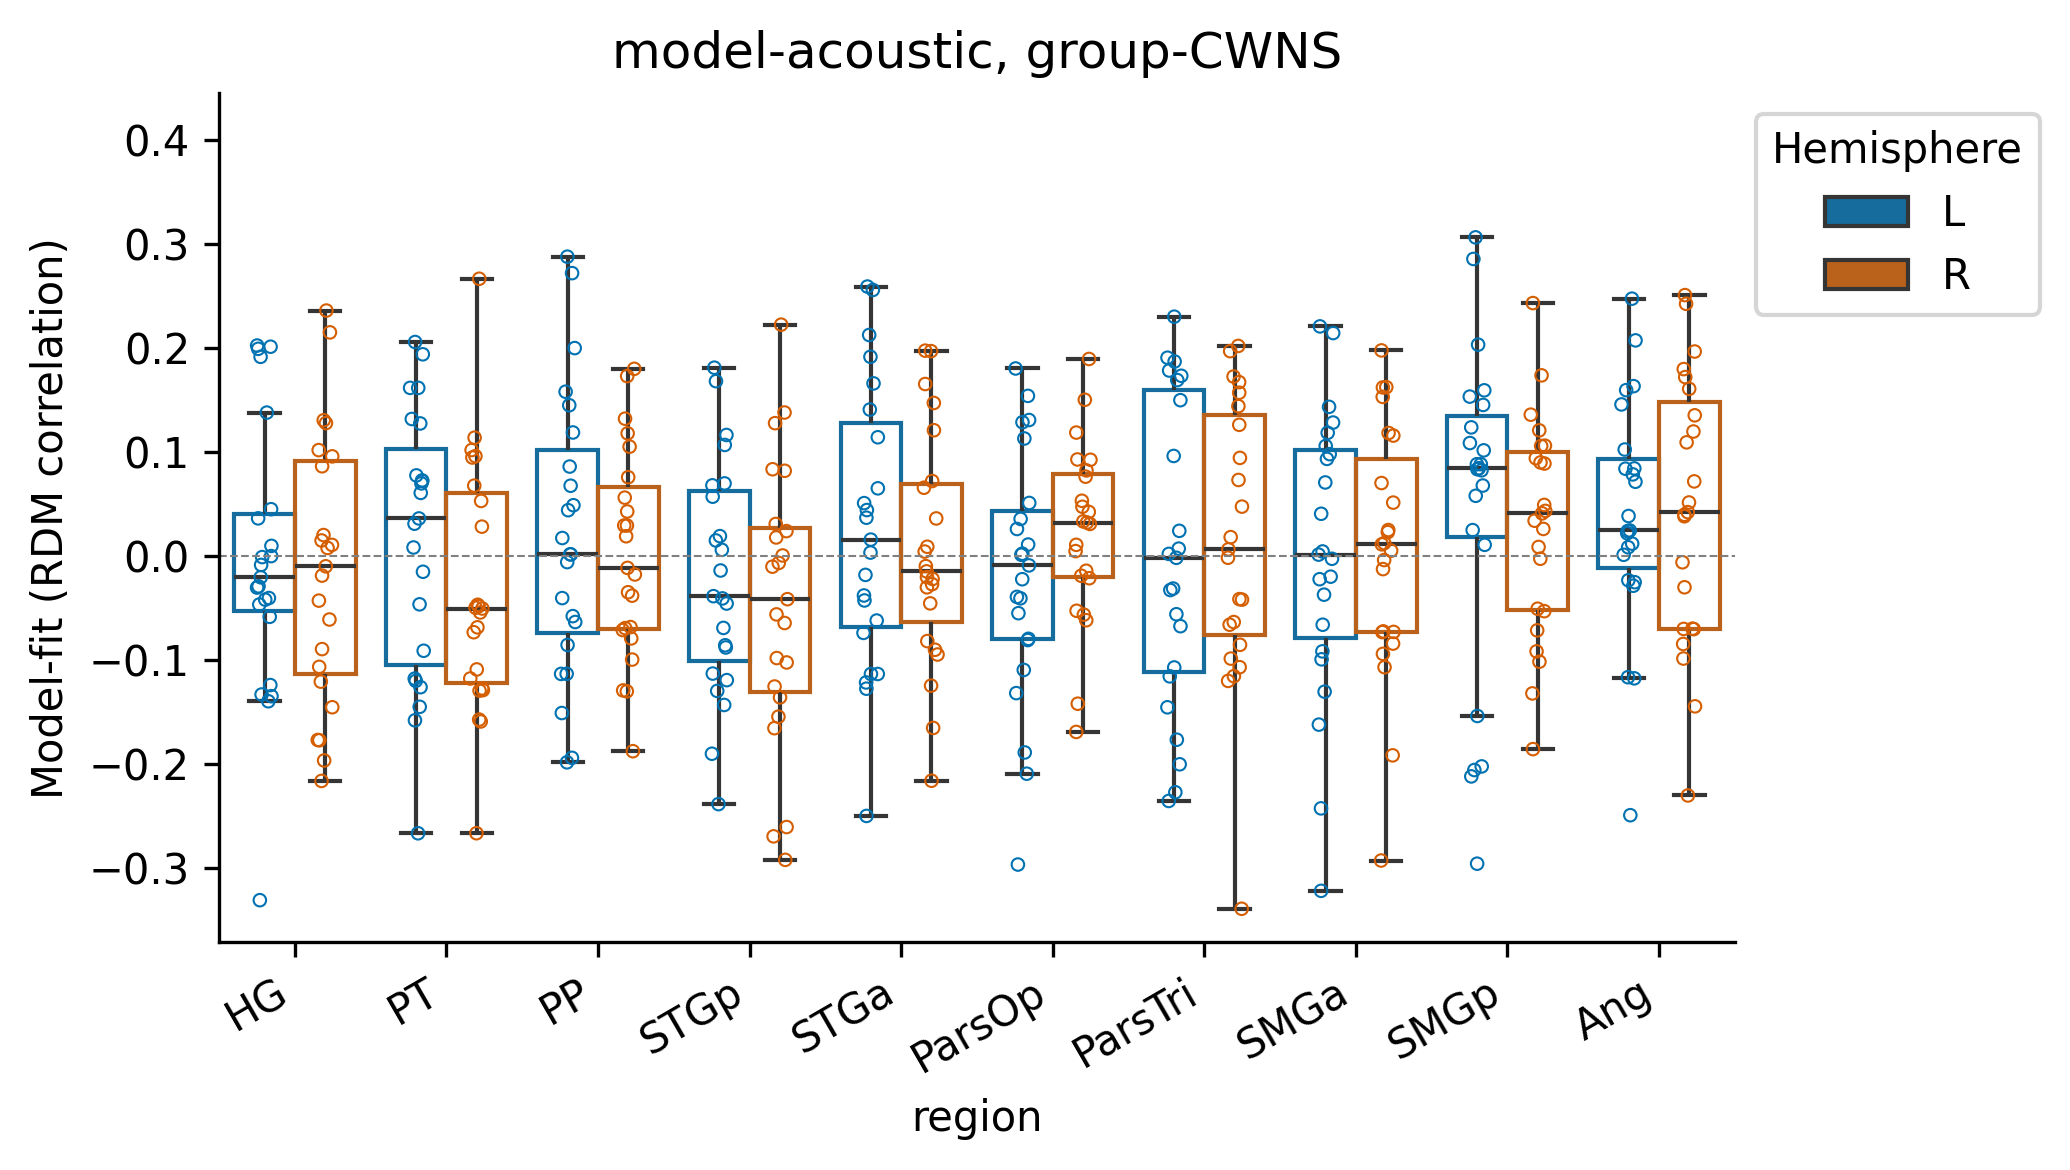

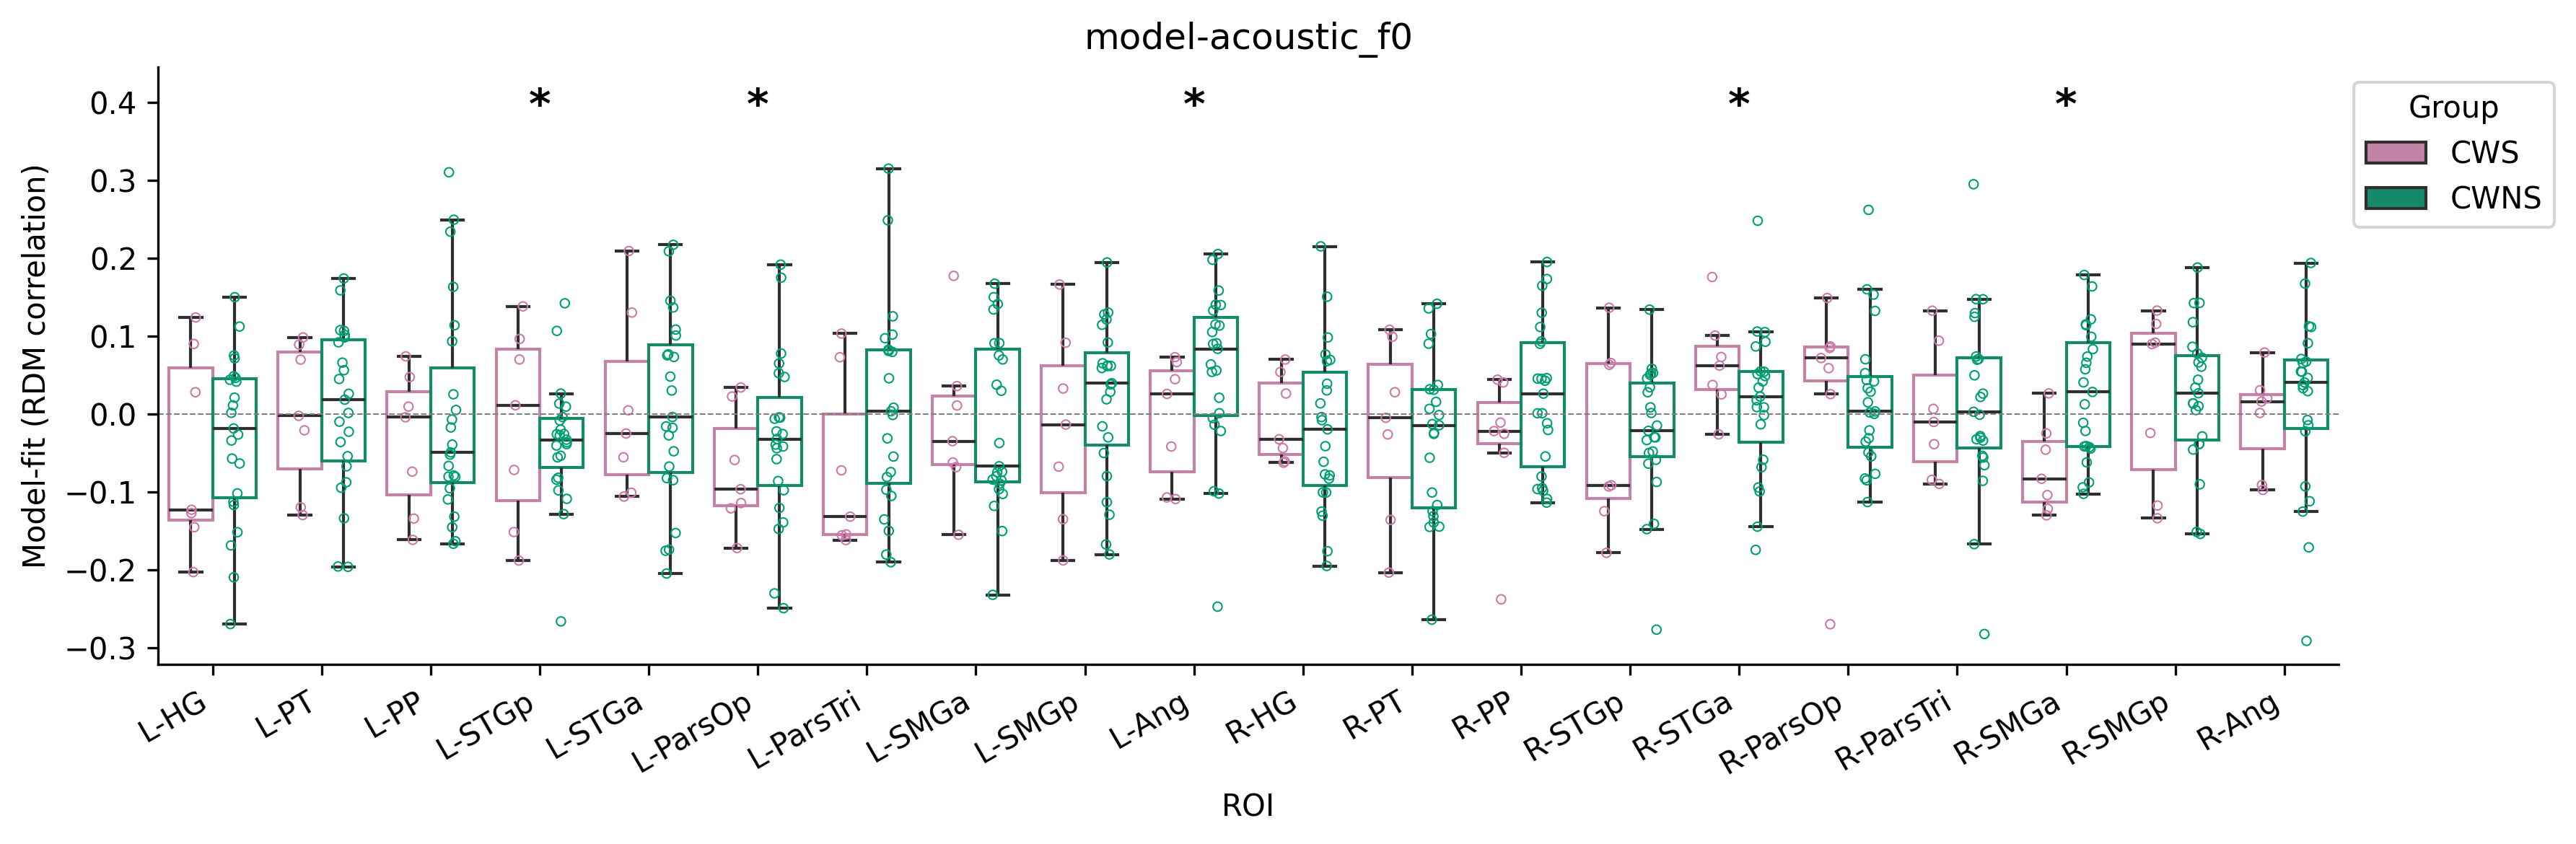

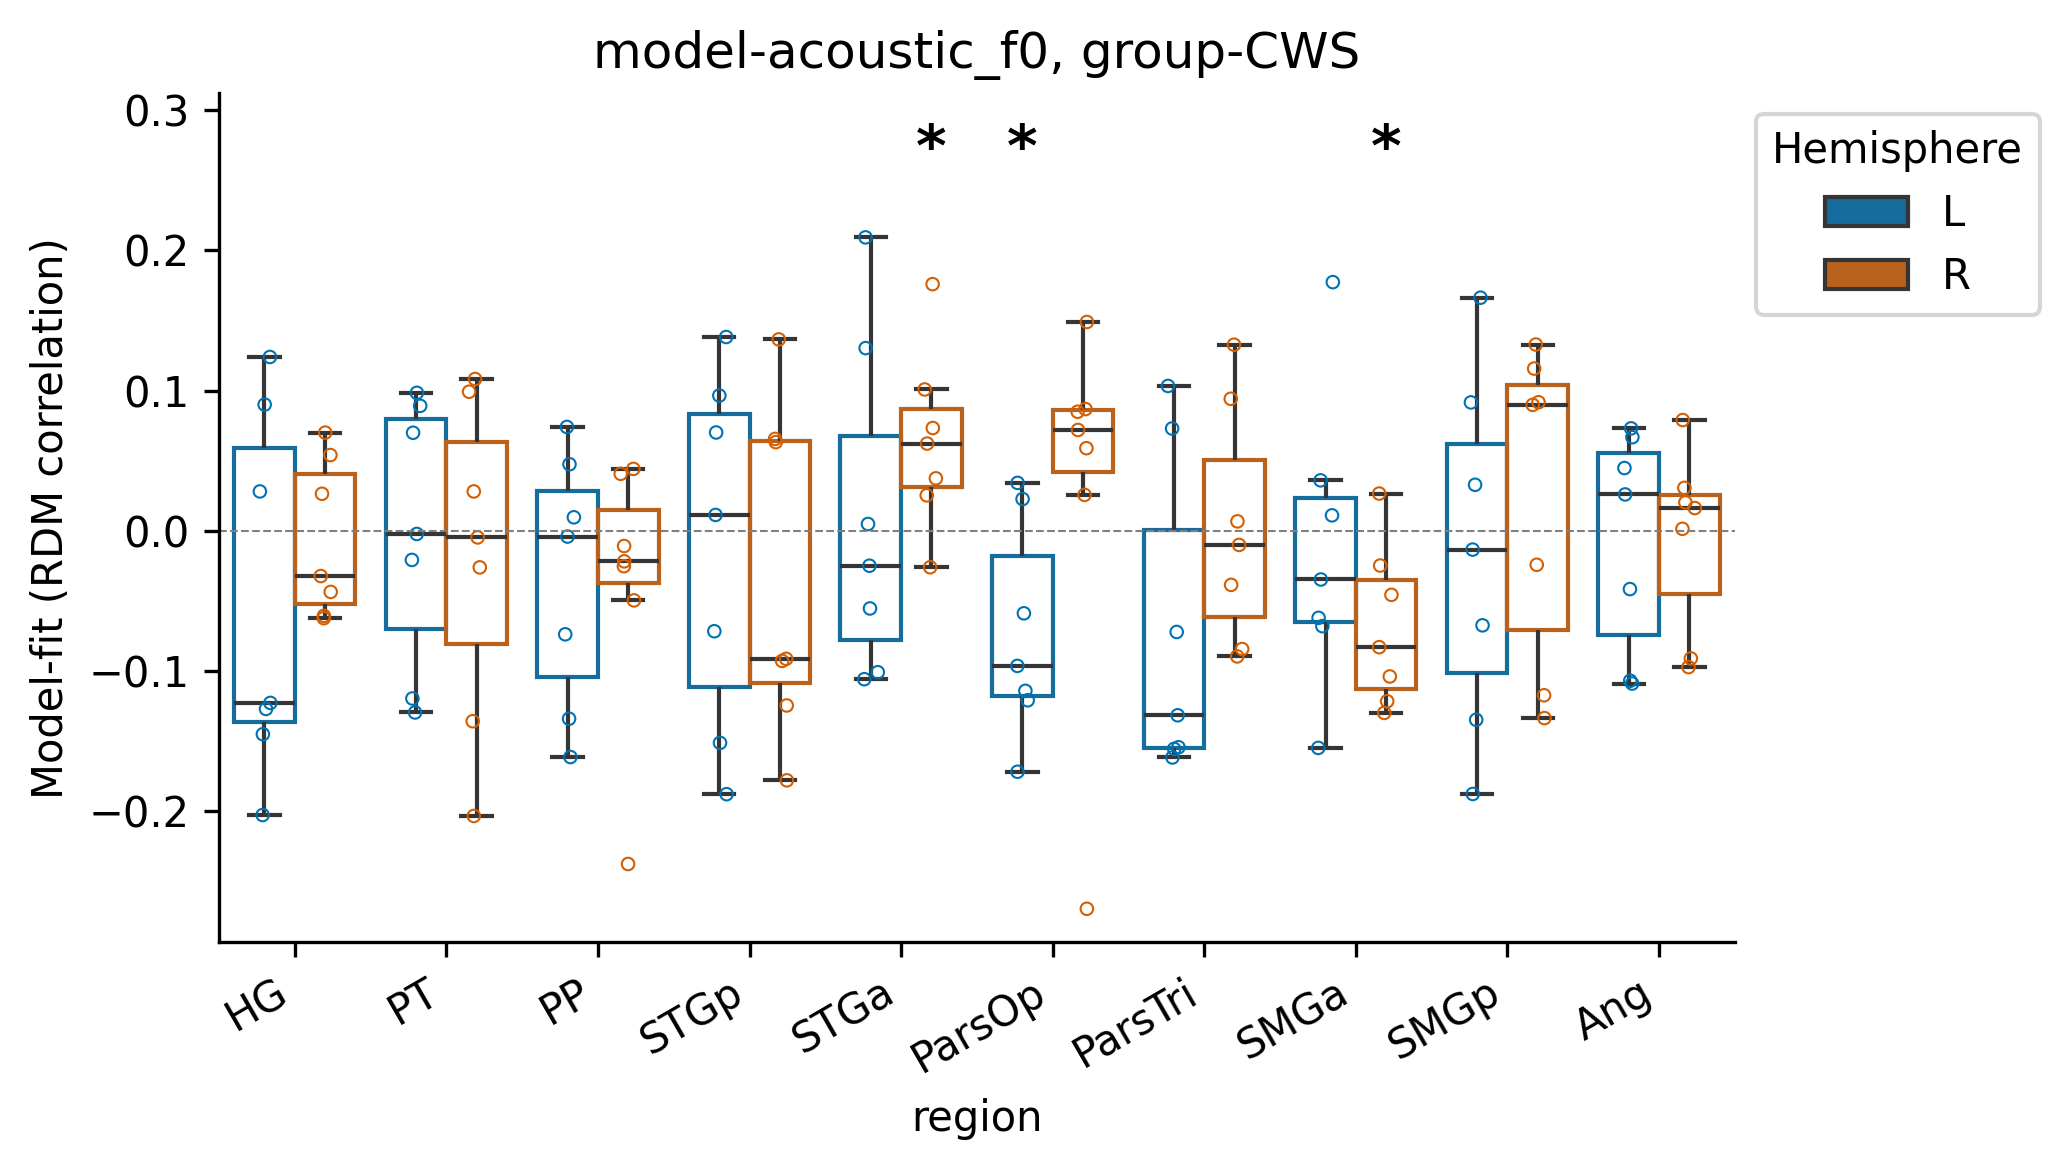

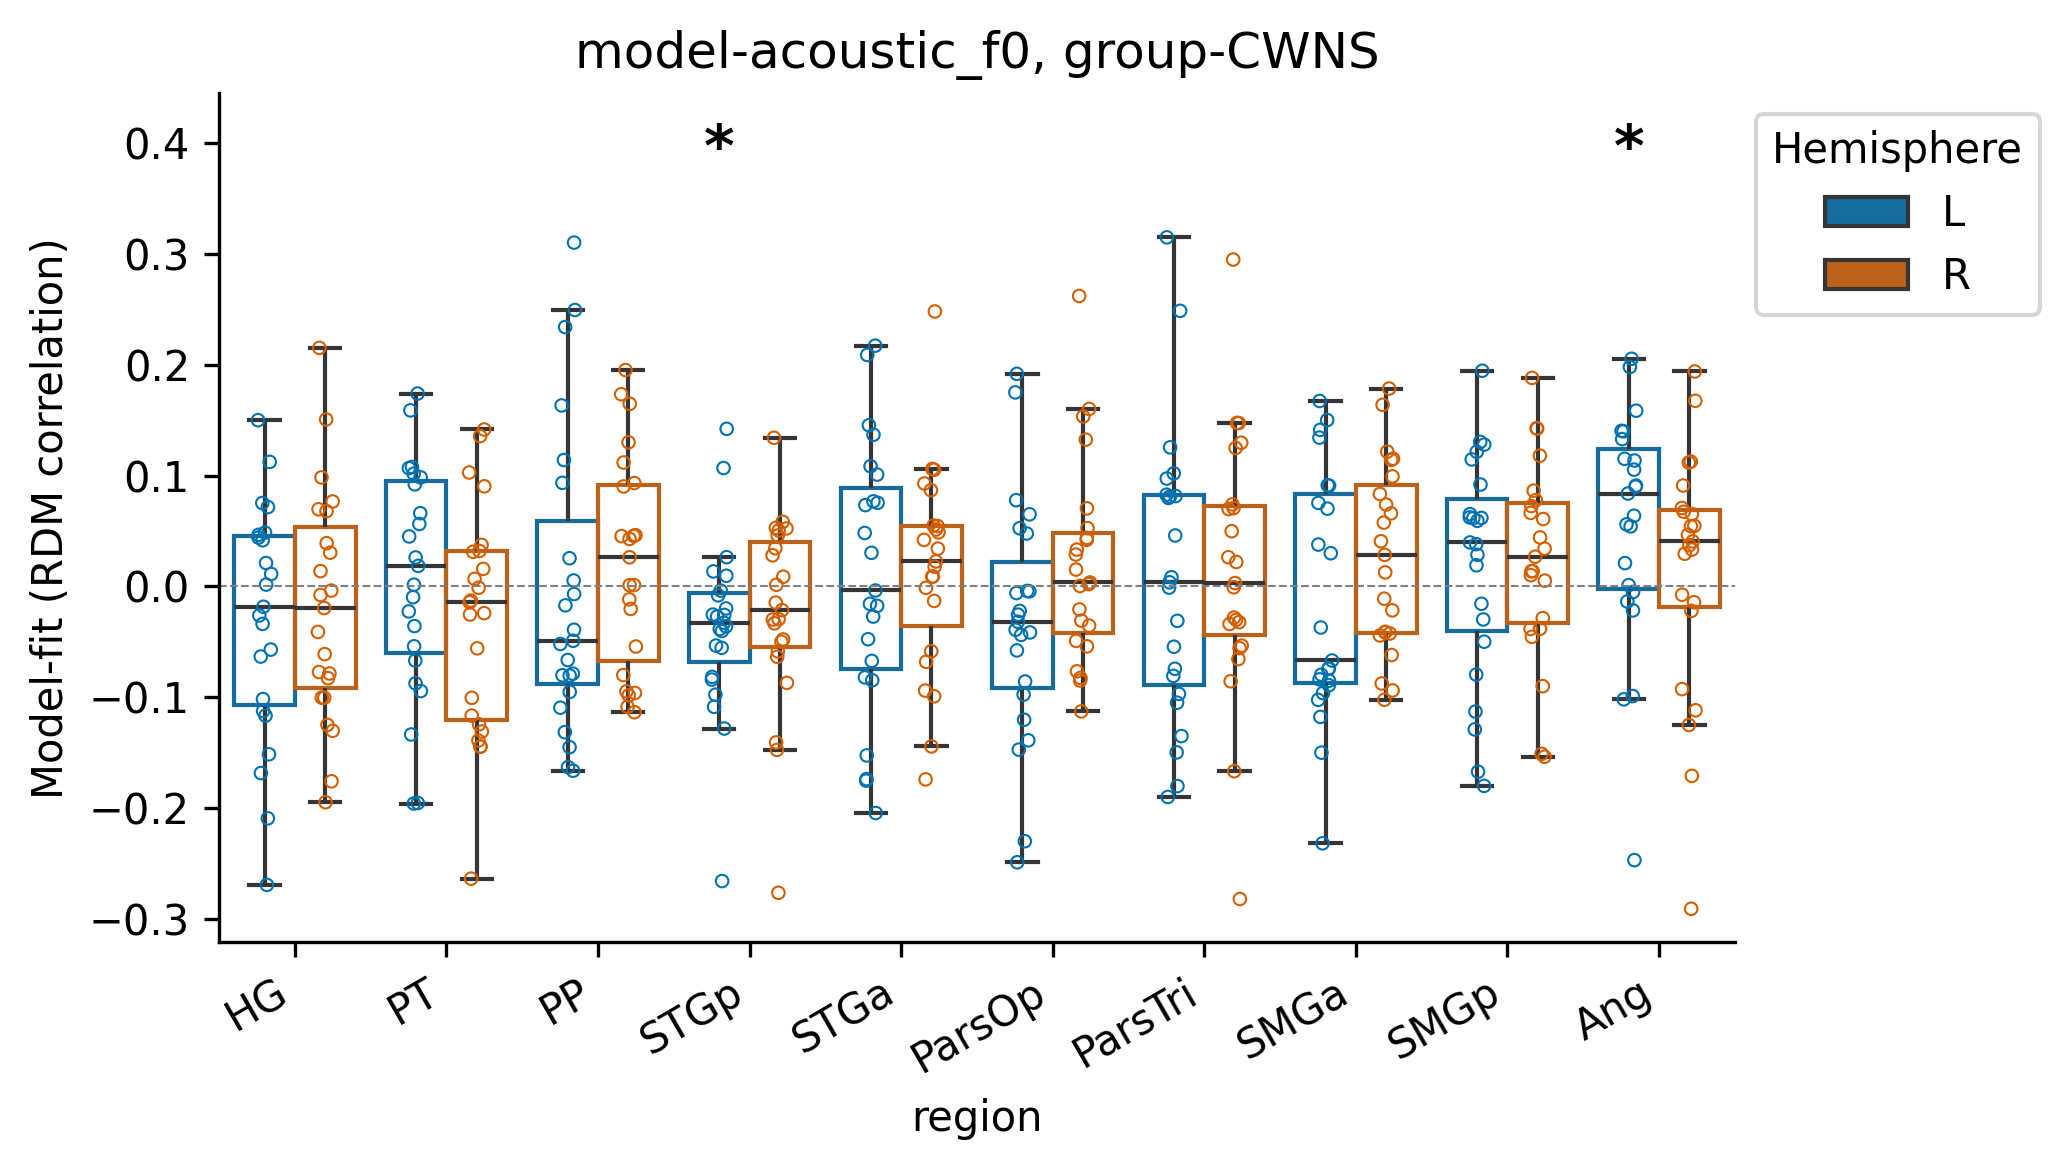

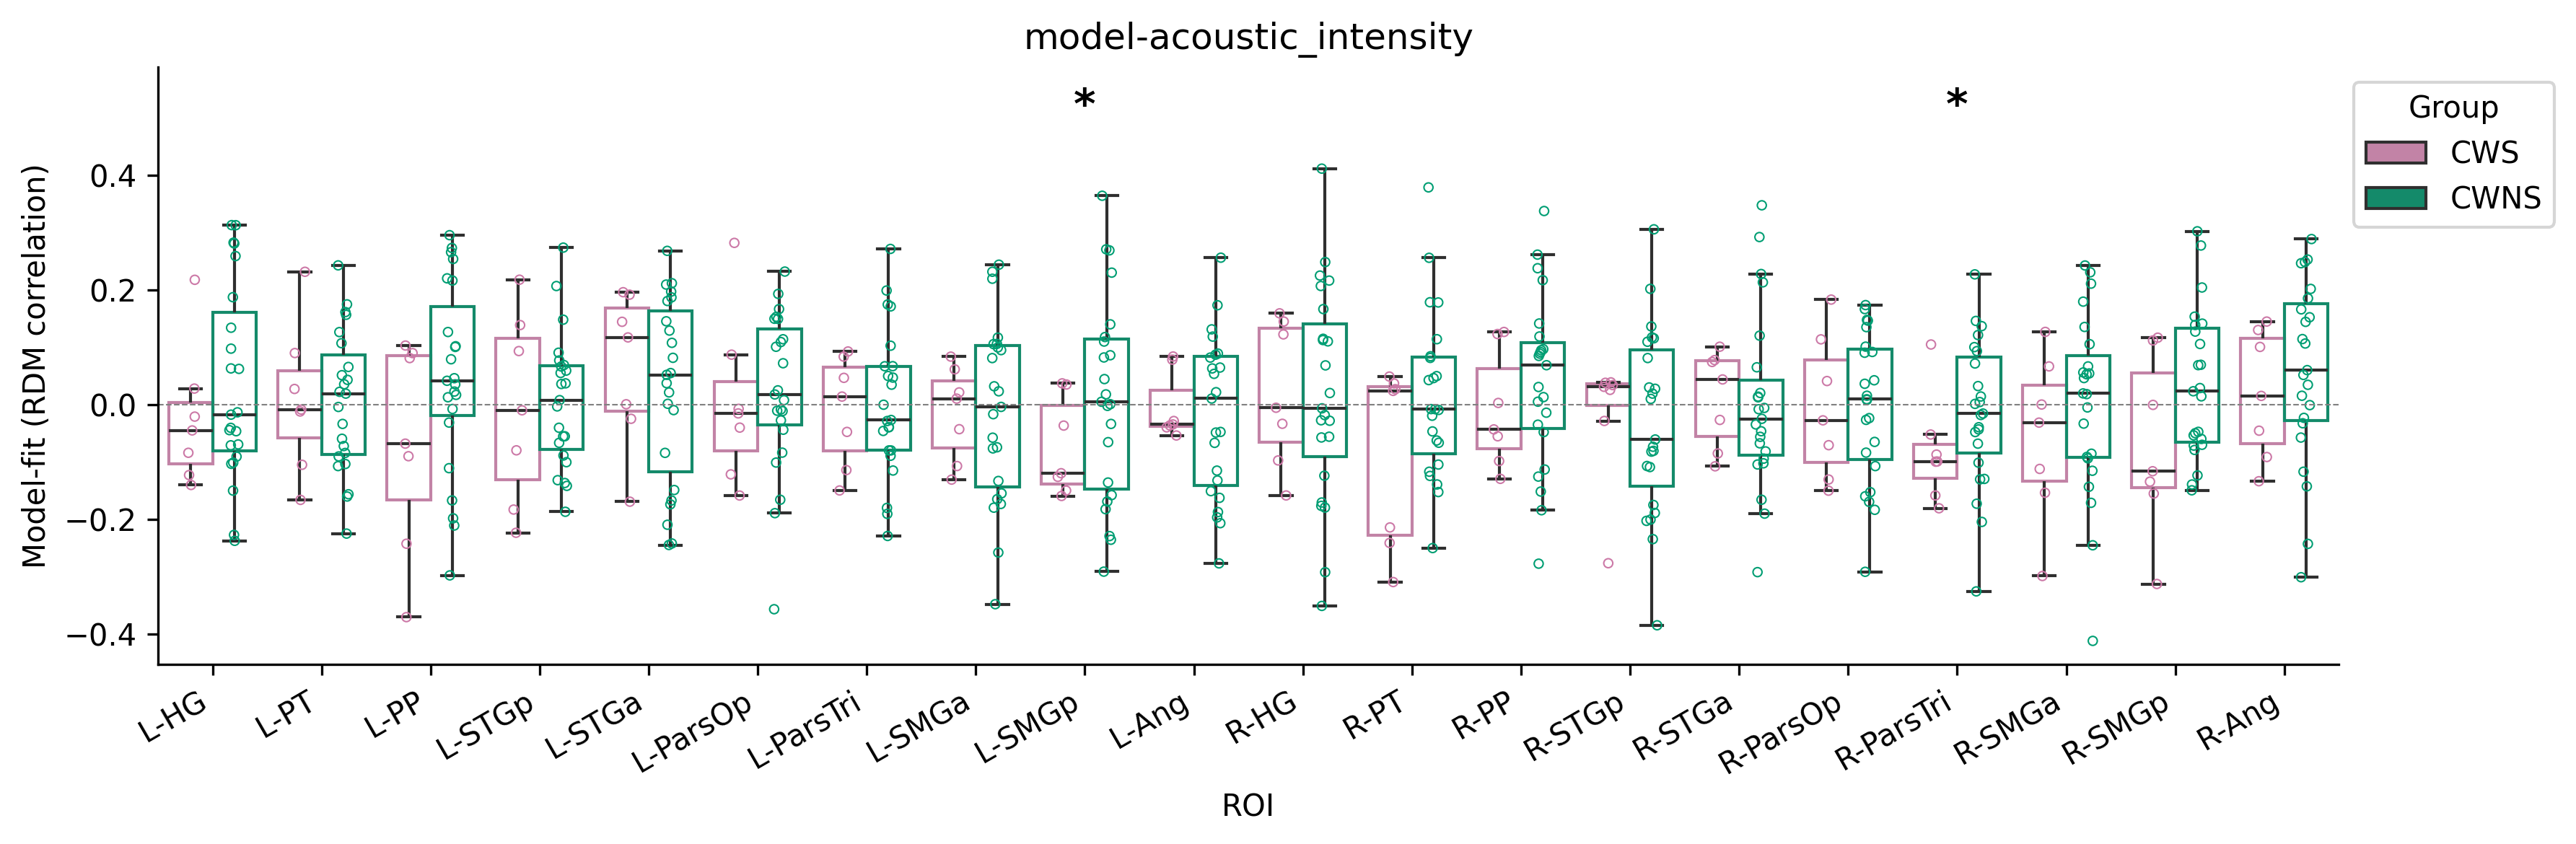

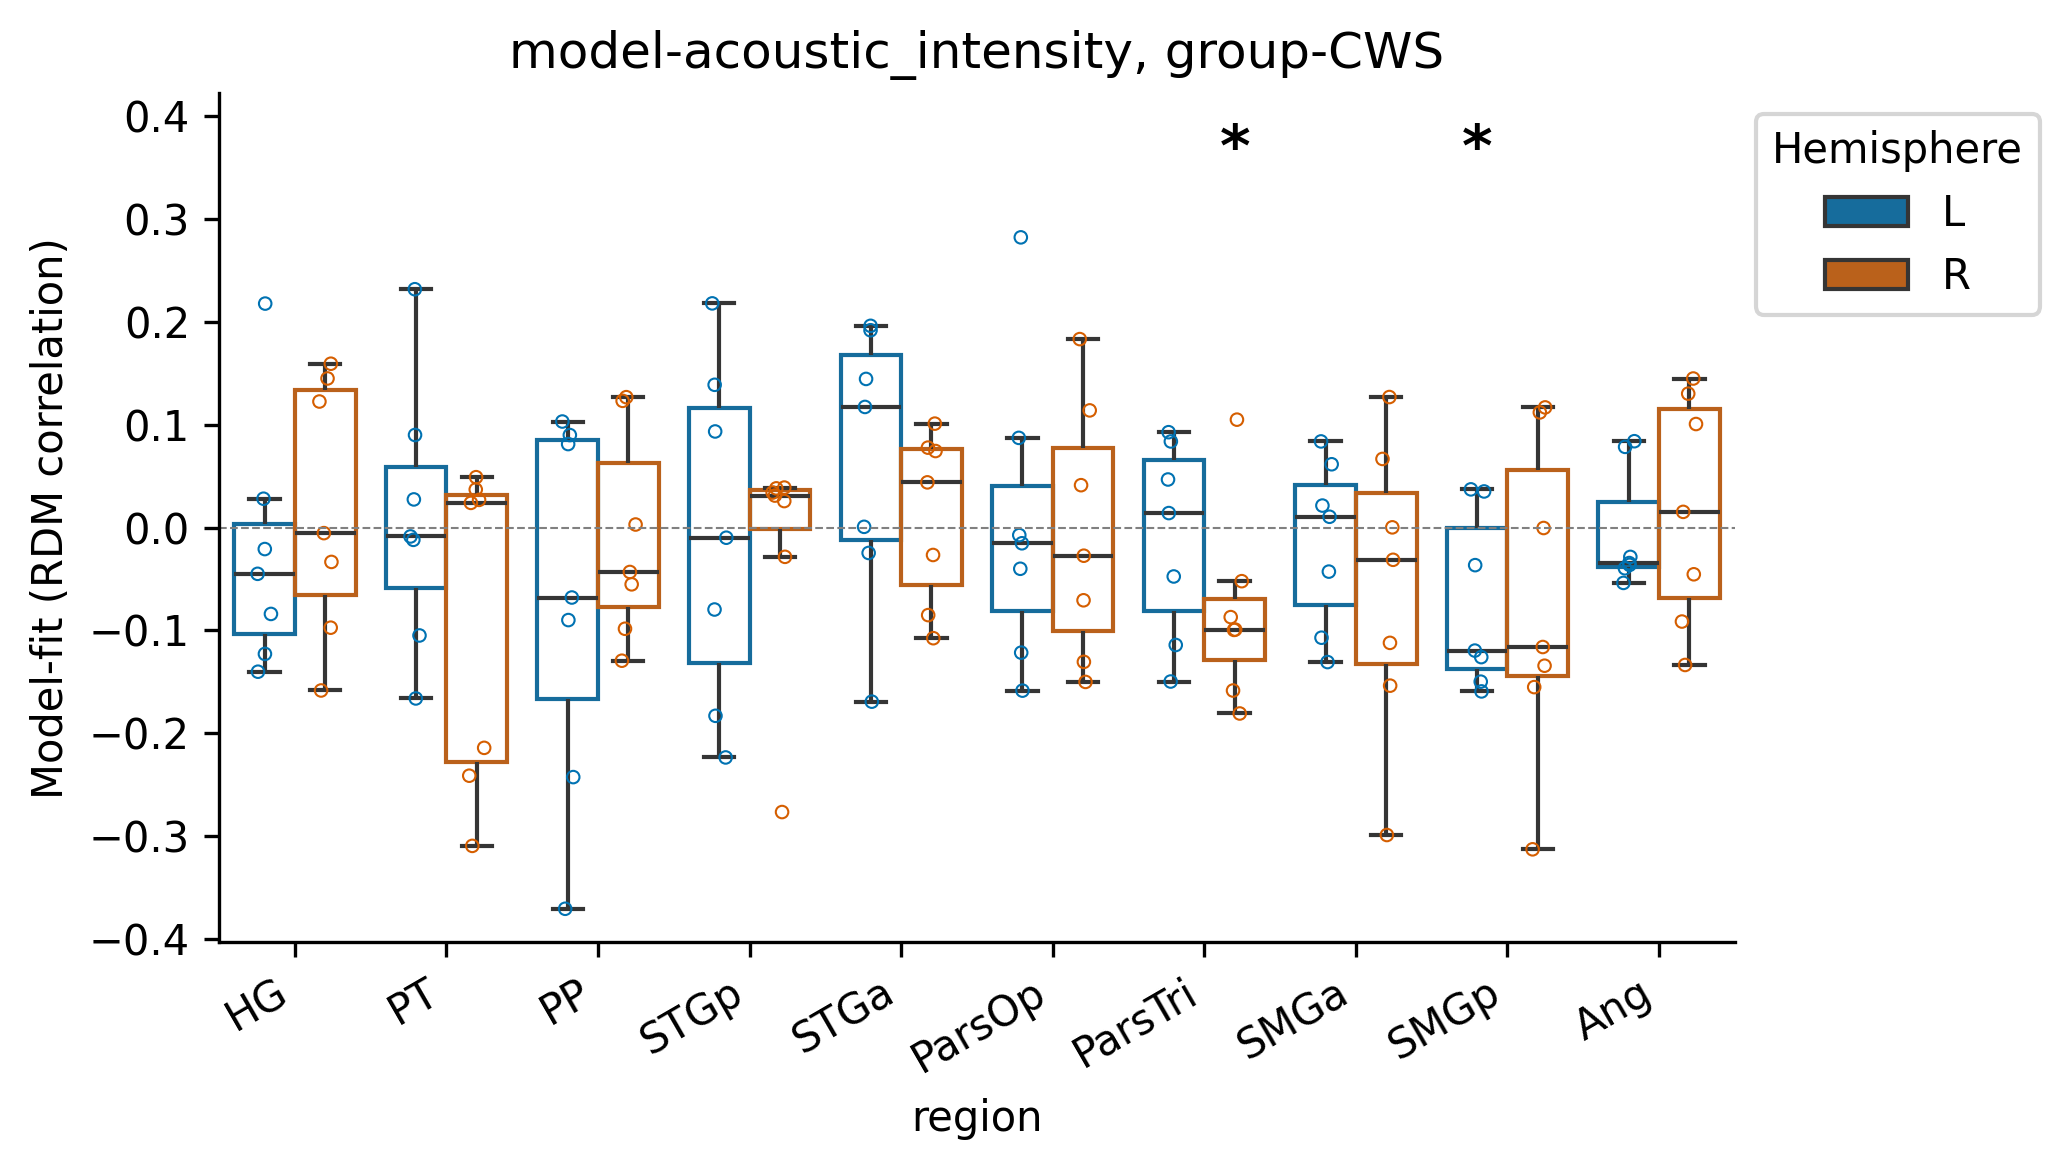

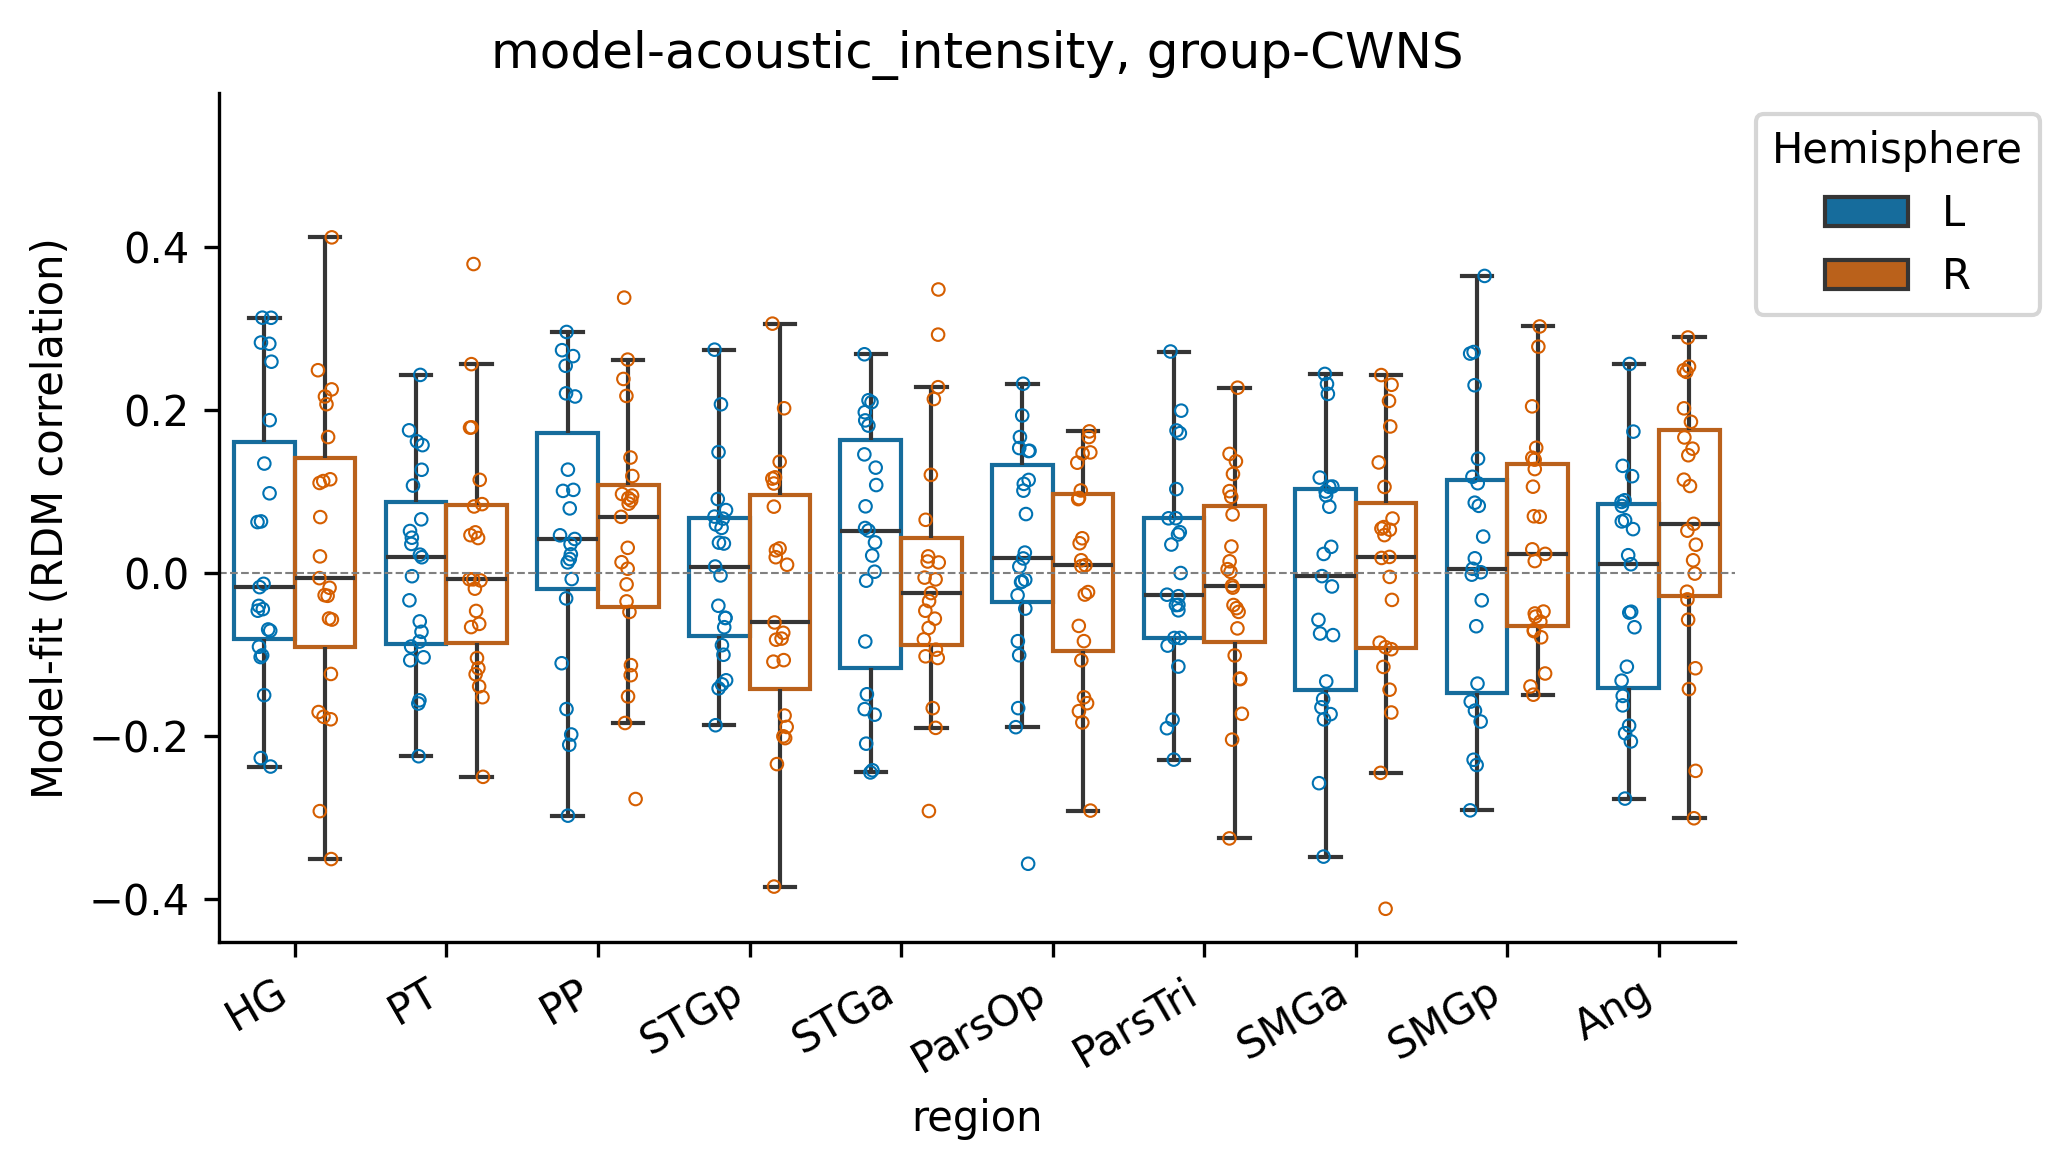

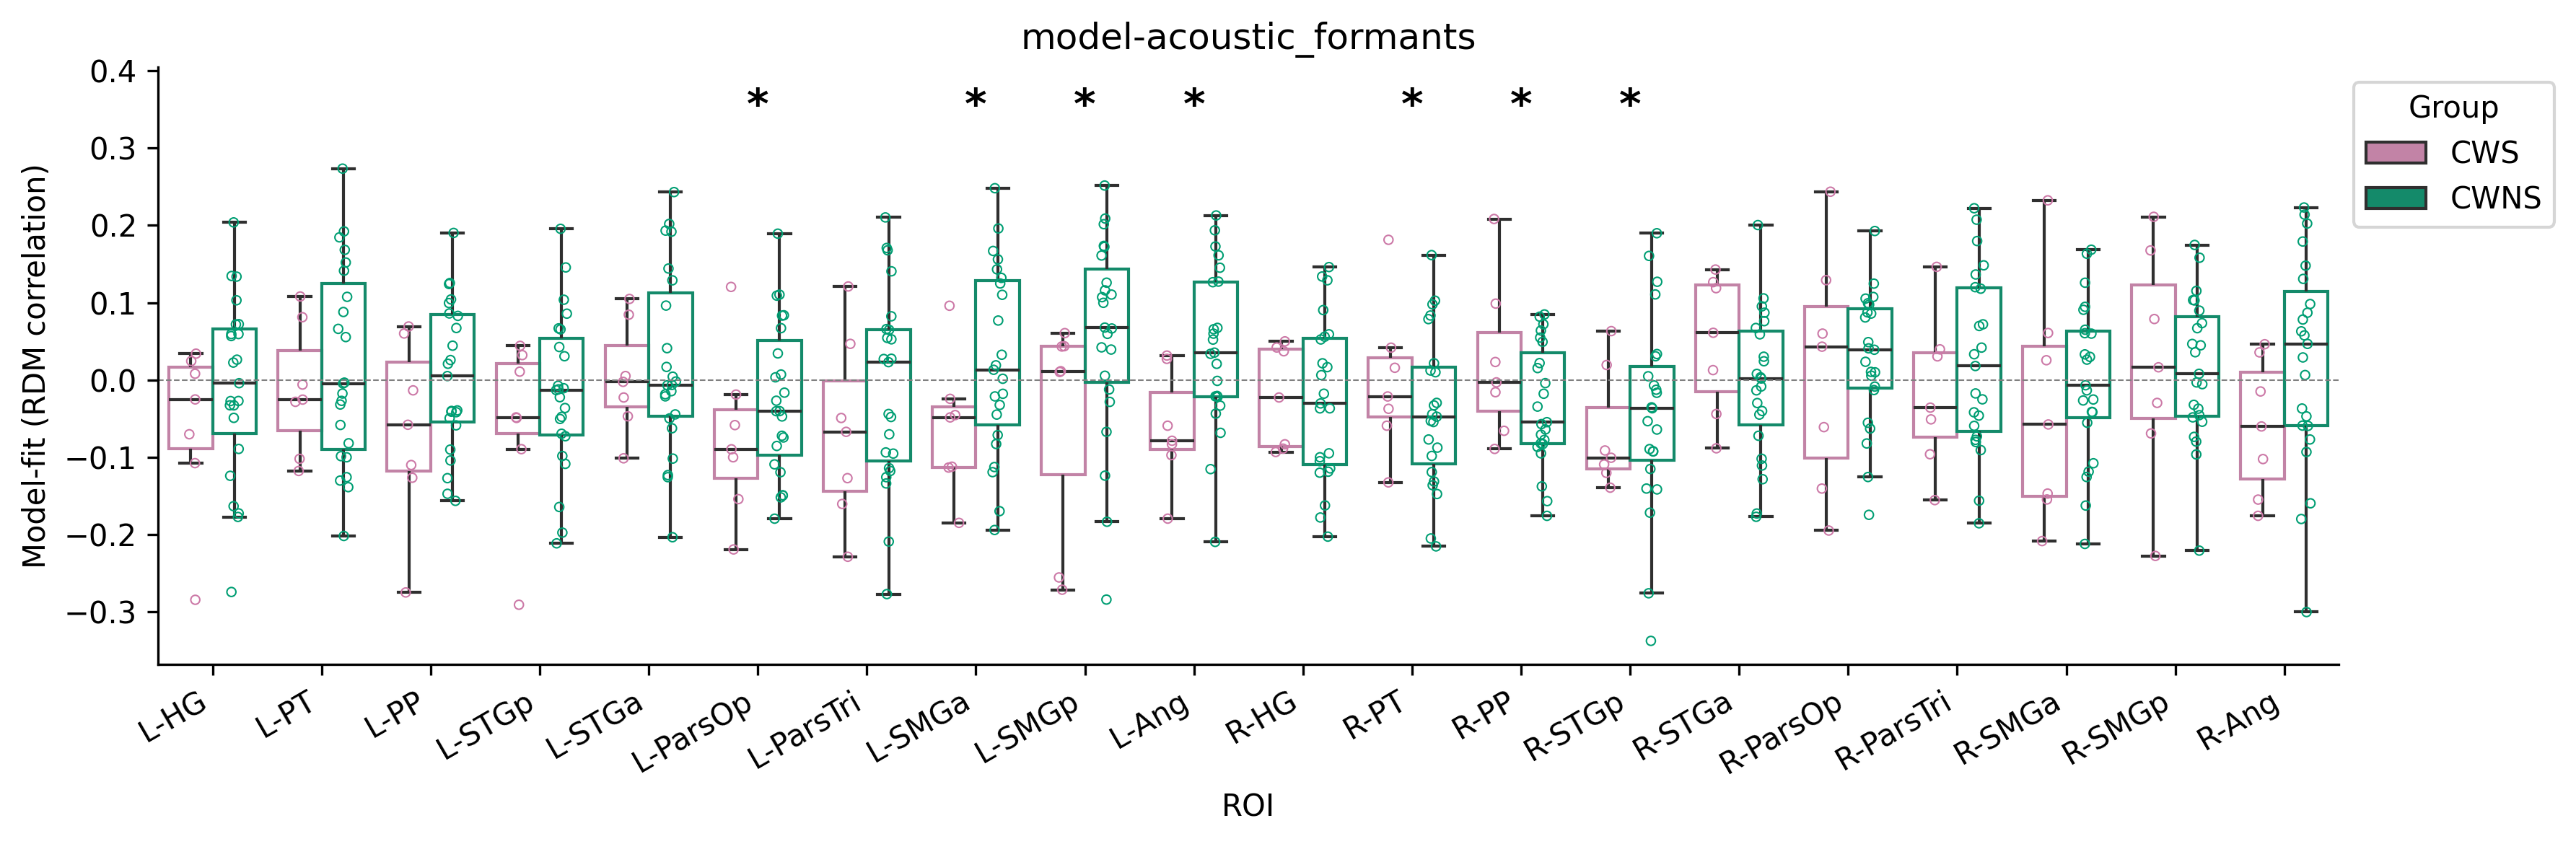

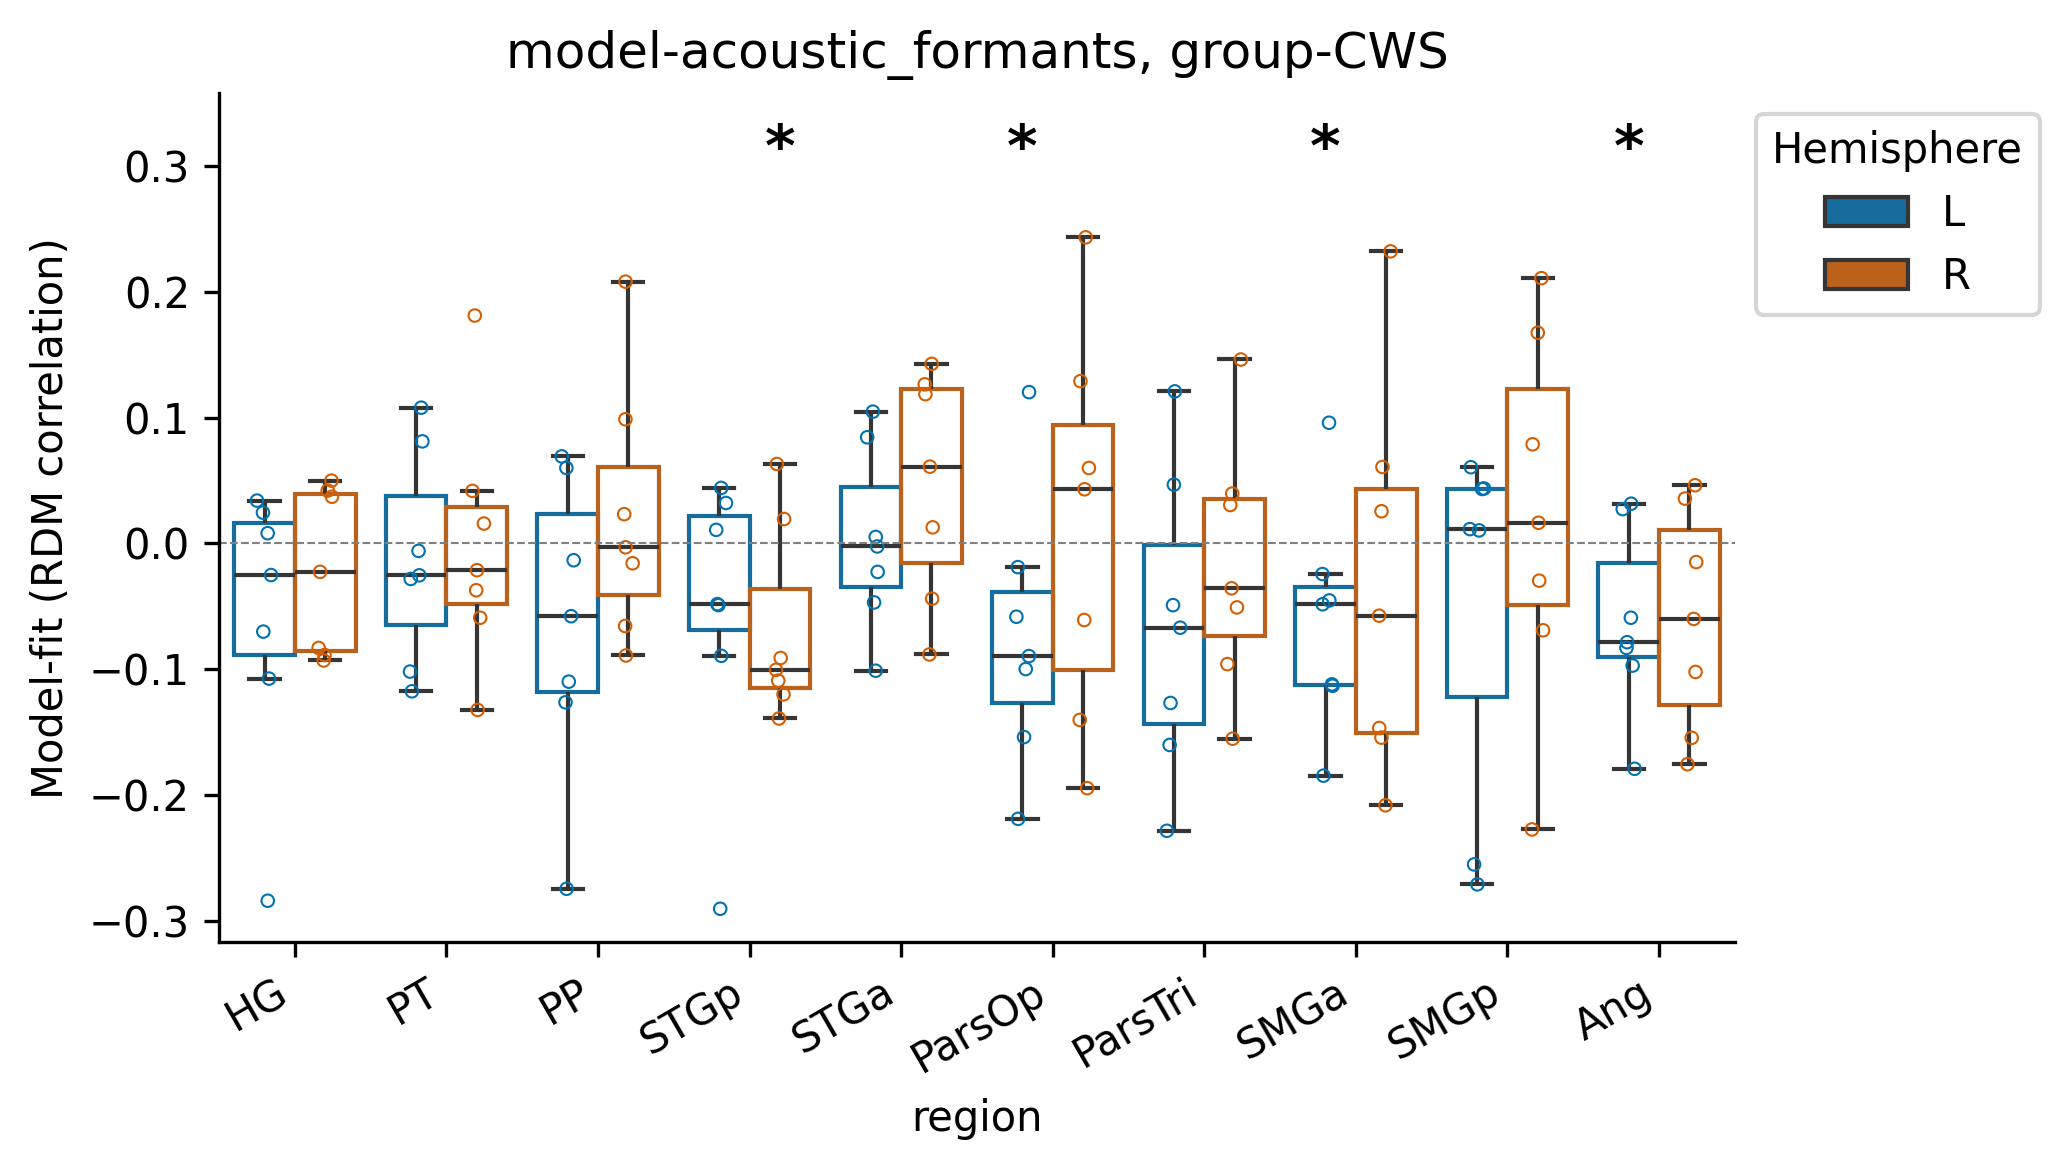

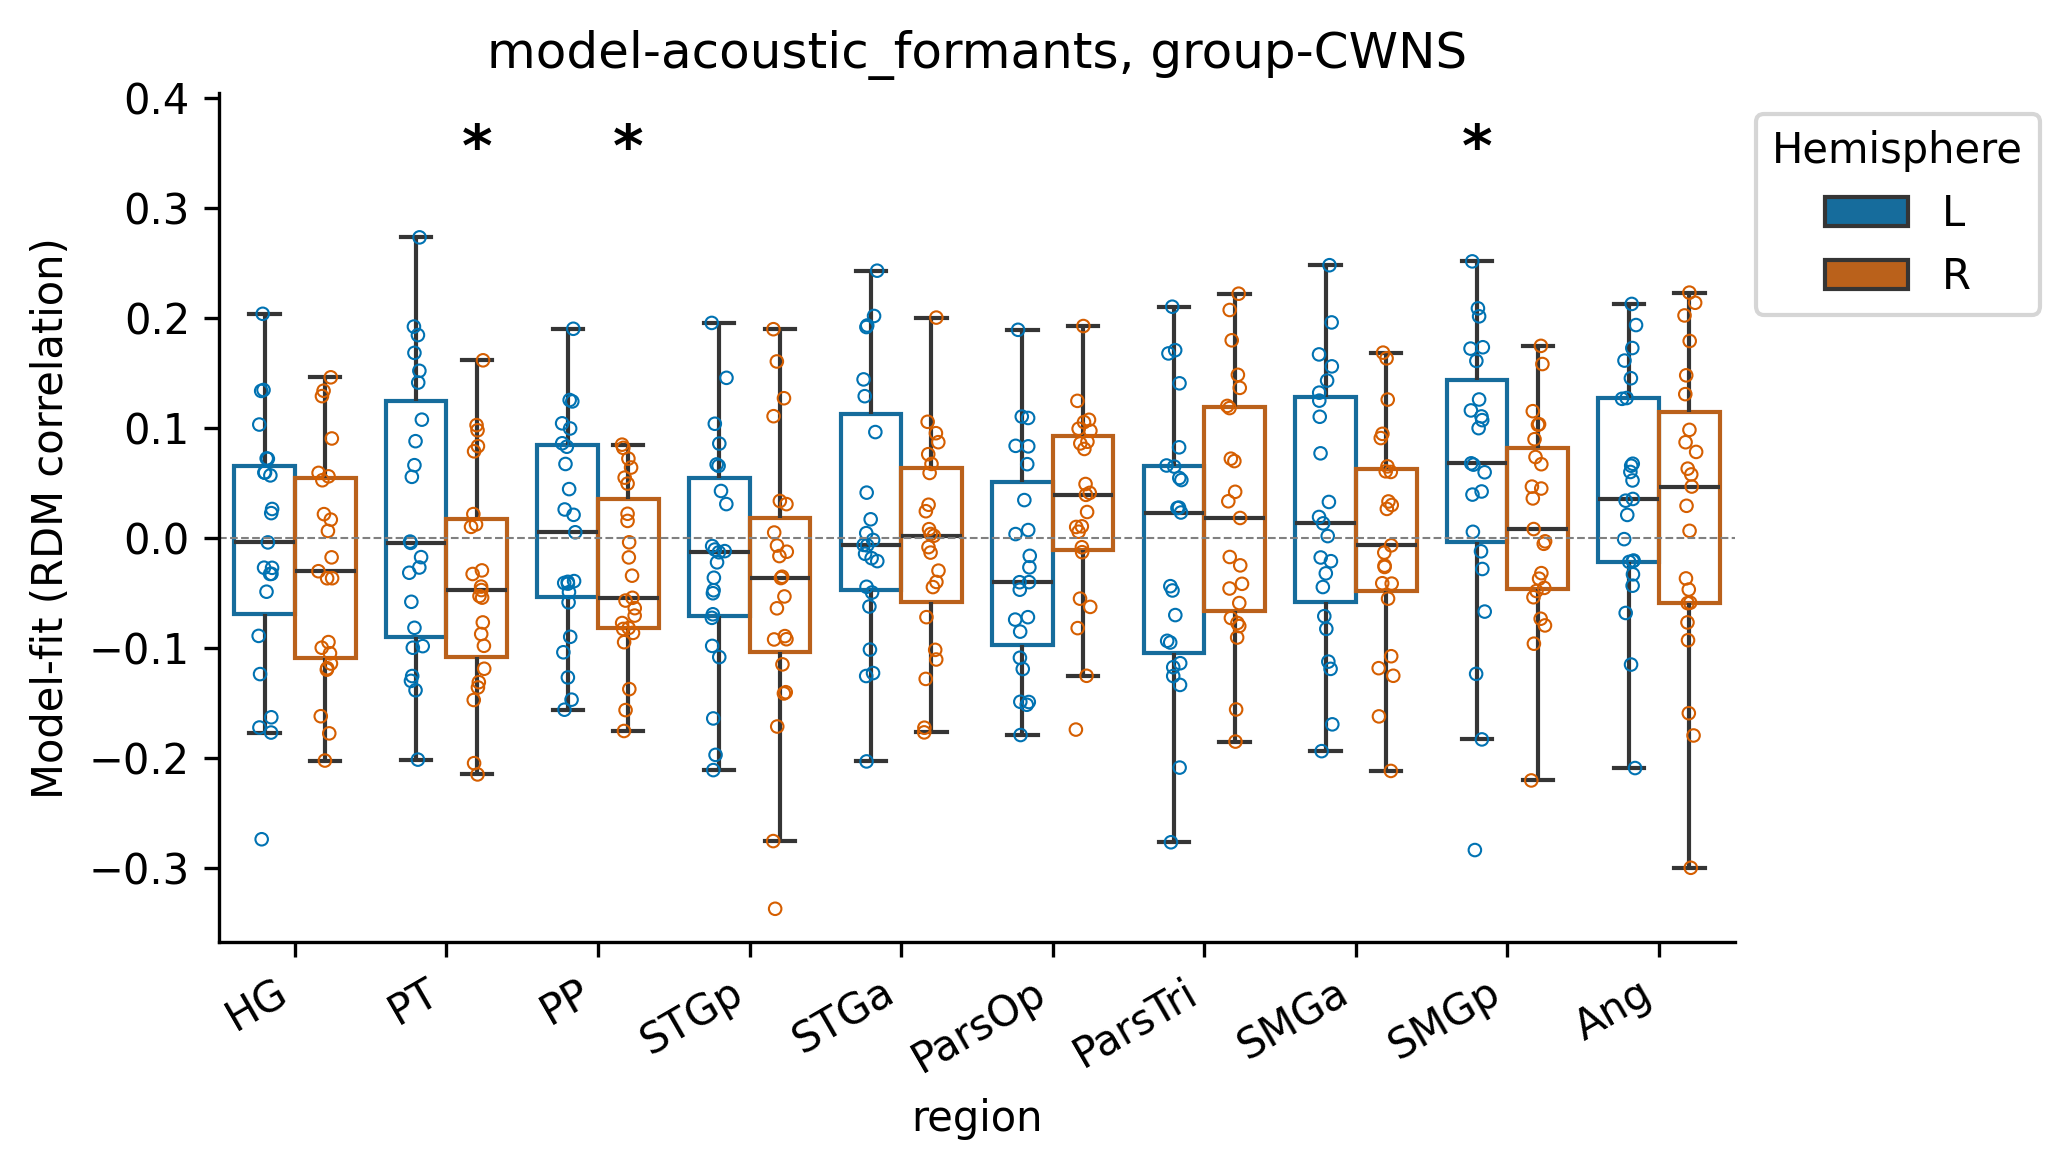

In [13]:
def _outline_only(ax):
    """Strip fill from stripplot dots and boxplot boxes, re-applying each hue group's original
    fill color as the outline/edge color first -- so the now-transparent shapes are still
    outlined in the color they're assigned, rather than whatever default edge color seaborn
    would otherwise leave them with.
    """
    for collection in ax.collections:
        facecolor = collection.get_facecolor()
        collection.set_edgecolor(facecolor)
        collection.set_facecolor('none')
    for patch in ax.patches:
        facecolor = patch.get_facecolor()
        patch.set_edgecolor(facecolor)
        patch.set_facecolor('none')


def _add_asterisk_headroom(ax, y_top):
    """Compute an asterisk y-position with headroom above the highest data point, and expand
    the axes' y-limit to guarantee that headroom doesn't get clipped or collide with the title.
    NOTE: previously this used `y_top * 1.05`, which pushes the asterisk *down* (not up) whenever
    y_top is negative or near zero -- a real bug for model-fit values that can be small/negative.
    Using a fixed fraction of the actual visible y-range instead is correct regardless of sign.
    """
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    asterisk_y = y_top + 0.08 * y_range
    ax.set_ylim(y_min, y_max + 0.15 * y_range)
    return asterisk_y


GROUP_ORDER = ['CWS', 'CWNS']
GROUP_PALETTE = {'CWNS': '#009E73', 'CWS': '#CC79A7'}  # bluish-green / reddish-purple
GROUP_OFFSET = {'CWS': -0.2, 'CWNS': 0.2}  # mirrors HEMISPHERE_OFFSET's dodge convention below


def plot_roi_box_strip(model_fit_df, within_group_significance_df, noise_ceiling_df, model_name, roi_order):
    model_df = model_fit_df[model_fit_df.model == model_name]

    fig, ax = plt.subplots(1, 1, figsize=(0.5 * len(roi_order) + 2, 4), dpi=300)

    sns.stripplot(data=model_df, x='ROI', y='fit', hue='group', order=roi_order,
                 hue_order=GROUP_ORDER, palette=GROUP_PALETTE,
                 dodge=True, linewidth=0.5, size=3, legend=None, ax=ax, zorder=2)
    sns.boxplot(data=model_df, x='ROI', y='fit', hue='group', order=roi_order,
               hue_order=GROUP_ORDER, palette=GROUP_PALETTE,
               dodge=True, linewidth=1, fliersize=0, ax=ax, zorder=1)
    _outline_only(ax)

    # noise ceiling: shaded band per (ROI, group) at that group's dodge position, in the same
    # color as the group's boxes (low alpha) so it reads as "this box's ceiling," not a new
    # category. Silently skipped for any (ROI, group) noise_ceiling_df doesn't have a row for
    # (e.g. fewer than 3 subjects -- see compute_noise_ceiling).
    for roi in roi_order:
        for group_name in GROUP_ORDER:
            ceiling_row = noise_ceiling_df[
                (noise_ceiling_df.ROI == roi) & (noise_ceiling_df.group == group_name)
            ]
            if len(ceiling_row) == 0:
                continue
            x = roi_order.index(roi) + GROUP_OFFSET[group_name]
            ax.fill_between([x - 0.08, x + 0.08],
                            ceiling_row['ceiling_lower'].iloc[0], ceiling_row['ceiling_upper'].iloc[0],
                            color=GROUP_PALETTE[group_name], alpha=0.25, zorder=0, linewidth=0)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), title='Group')
    ax.axhline(y=0, color='0.5', linestyle='--', linewidth=0.5)
    ax.set_ylabel('Model-fit (RDM correlation)')
    ax.set_title(f'model-{model_name}')

    # mark ROIs with ANY significant (FDR-corrected) within-group effect (either group)
    y_top = model_df['fit'].max()
    asterisk_y = _add_asterisk_headroom(ax, y_top)
    sig_rois = within_group_significance_df[
        (within_group_significance_df.model == model_name) &
        (within_group_significance_df.p_fdr < 0.05)
    ]['ROI'].unique()
    for roi in sig_rois:
        if roi in roi_order:
            ax.text(roi_order.index(roi), asterisk_y, '*', ha='center', va='bottom',
                    fontsize=14, fontweight='bold')

    fig.tight_layout()
    sns.despine(ax=ax)
    return fig


# Seaborn's default dodge for 2 hue categories with the default box width (0.8) centers each
# hue's sub-box at +/-0.2 from the category tick position. This is a best-effort approximation
# of seaborn's internal dodge math (no local seaborn install to verify exact positions against)
# -- check visually on first real render and adjust if asterisks don't land exactly over their
# boxes. hue_order is passed explicitly to both plot calls below so 'L' is always hue index 0
# (offset -0.2) and 'R' is always index 1 (offset +0.2), rather than relying on whatever order
# seaborn would otherwise infer from the data.
HEMISPHERE_ORDER = ['L', 'R']
HEMISPHERE_OFFSET = {'L': -0.2, 'R': 0.2}
HEMISPHERE_PALETTE = {'L': '#0072B2', 'R': '#D55E00'}  # blue / vermillion


def plot_roi_box_strip_by_hemisphere(model_fit_df, within_group_significance_df, noise_ceiling_df,
                                     model_name, group_name, region_order):
    """Group-specific variant: x=region (hemisphere prefix stripped), hue=hemisphere. Fewer
    x-categories than plot_roi_box_strip's combined (x=ROI, hue=group) view -- one figure per
    (model, group) instead of one per model. Asterisks are placed over the specific L or R box
    (not the region's center), so significance is shown per-hemisphere, not pooled across both.
    """
    group_df = model_fit_df[(model_fit_df.model == model_name) & (model_fit_df.group == group_name)].copy()
    group_df['hemisphere'] = group_df['ROI'].str.split('-', n=1).str[0]
    group_df['region'] = group_df['ROI'].str.split('-', n=1).str[1]

    fig, ax = plt.subplots(1, 1, figsize=(0.5 * len(region_order) + 2, 4), dpi=300)

    sns.stripplot(data=group_df, x='region', y='fit', hue='hemisphere', order=region_order,
                 hue_order=HEMISPHERE_ORDER, palette=HEMISPHERE_PALETTE,
                 dodge=True, linewidth=0.5, size=3, legend=None, ax=ax, zorder=2)
    sns.boxplot(data=group_df, x='region', y='fit', hue='hemisphere', order=region_order,
               hue_order=HEMISPHERE_ORDER, palette=HEMISPHERE_PALETTE,
               dodge=True, linewidth=1, fliersize=0, ax=ax, zorder=1)
    _outline_only(ax)

    # noise ceiling: shaded band per (region, hemisphere) at that hemisphere's dodge position,
    # scoped to this plot's single group_name.
    for region_idx, region in enumerate(region_order):
        for hemi, offset in HEMISPHERE_OFFSET.items():
            roi_name = f'{hemi}-{region}'
            ceiling_row = noise_ceiling_df[
                (noise_ceiling_df.ROI == roi_name) & (noise_ceiling_df.group == group_name)
            ]
            if len(ceiling_row) == 0:
                continue
            x = region_idx + offset
            ax.fill_between([x - 0.08, x + 0.08],
                            ceiling_row['ceiling_lower'].iloc[0], ceiling_row['ceiling_upper'].iloc[0],
                            color=HEMISPHERE_PALETTE[hemi], alpha=0.25, zorder=0, linewidth=0)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), title='Hemisphere')
    ax.axhline(y=0, color='0.5', linestyle='--', linewidth=0.5)
    ax.set_ylabel('Model-fit (RDM correlation)')
    ax.set_title(f'model-{model_name}, group-{group_name}')

    # mark the SPECIFIC L or R box (FDR-corrected) with an asterisk, per-hemisphere, using the
    # dodge offsets above
    y_top = group_df['fit'].max()
    asterisk_y = _add_asterisk_headroom(ax, y_top)
    sig_rois_set = set(within_group_significance_df[
        (within_group_significance_df.model == model_name) &
        (within_group_significance_df.group == group_name) &
        (within_group_significance_df.p_fdr < 0.05)
    ]['ROI'])
    for hemi, offset in HEMISPHERE_OFFSET.items():
        for region_idx, region in enumerate(region_order):
            if f'{hemi}-{region}' in sig_rois_set:
                ax.text(region_idx + offset, asterisk_y, '*', ha='center', va='bottom',
                        fontsize=14, fontweight='bold')

    fig.tight_layout()
    sns.despine(ax=ax)
    return fig


for model_name in model_rdms.keys():
    fig = plot_roi_box_strip(model_fit_df, within_group_significance_df, noise_ceiling_df, model_name, CORTICAL_ROI_LIST)
    fig.savefig(os.path.join(out_dir, f'boxplot_model-{model_name}_noiselevel-{NOISE_LEVEL_TAG}.png'))
    fig.savefig(os.path.join(out_dir, f'boxplot_model-{model_name}_noiselevel-{NOISE_LEVEL_TAG}.svg'))

    for group_name in ['CWS', 'CWNS']:
        fig = plot_roi_box_strip_by_hemisphere(model_fit_df, within_group_significance_df, noise_ceiling_df,
                                               model_name, group_name, BASE_REGION_ORDER)
        fig.savefig(os.path.join(
            out_dir, f'boxplot_model-{model_name}_group-{group_name}_by-hemisphere_noiselevel-{NOISE_LEVEL_TAG}.png'))
        fig.savefig(os.path.join(
            out_dir, f'boxplot_model-{model_name}_group-{group_name}_by-hemisphere_noiselevel-{NOISE_LEVEL_TAG}.svg'))

### Brain plots (surface-based)

Reuses `roi_surface_plotting.py` (copied from `fMRI_auditory-category-learning/`, unmodified)
to project per-ROI scalars onto the fsaverage surface. For each model, three panels matching
the CWNS/CWS/diff convention already used throughout this pipeline: CWS-mean model-fit,
CWNS-mean model-fit (both from the within-group significance test above), and the CWS-CWNS
bootstrap `observed_diff` (from the between-group comparison above).

In [14]:
from roi_surface_plotting import plot_roi_surface_stat, build_mask_path_dict

masks_dir = os.path.join(bidsroot, 'derivatives', 'nilearn', 'masks')
space_label = 'MNI152NLin2009cAsym'

# network_name='dseg' passed directly (the actual mask-directory atlas name), rather than adding
# a new 'cortical' branch to build_mask_path_dict's network_name->mask_network_name mapping --
# avoids touching the copied reference module at all.
mask_path_dict = build_mask_path_dict(CORTICAL_ROI_LIST, masks_dir, network_name='dseg', space_label=space_label)

In [15]:
# Precompute the per-model stat dicts once (fast -- no plotting yet). Splitting the actual
# plotting (slow: surface.vol_to_surf projects every vertex on the whole hemisphere surface,
# per ROI, per call) into separate cells below by comparison type (cws/cwns/diff) gives natural
# checkpoints -- if interrupted partway through, whichever cells already ran have their plots
# saved, and it's clear which comparison type is left to (re-)run.
stat_dicts_by_model = {}
for model_name in model_rdms.keys():
    cws_stat_dict = within_group_significance_df[
        (within_group_significance_df.model == model_name) &
        (within_group_significance_df.group == 'CWS')
    ].set_index('ROI')['observed_mean'].to_dict()
    cwns_stat_dict = within_group_significance_df[
        (within_group_significance_df.model == model_name) &
        (within_group_significance_df.group == 'CWNS')
    ].set_index('ROI')['observed_mean'].to_dict()
    diff_stat_dict = group_comparison_df[
        group_comparison_df.model == model_name
    ].set_index('ROI')['observed_diff'].to_dict()

    stat_dicts_by_model[model_name] = {'cws': cws_stat_dict, 'cwns': cwns_stat_dict, 'diff': diff_stat_dict}

print('models ready to plot:', list(stat_dicts_by_model.keys()))

models ready to plot: ['syllable', 'speaker', 'acoustic', 'acoustic_f0', 'acoustic_intensity', 'acoustic_formants']


In [23]:
def plot_and_save_surface(model_name, label, stat_dict):
    if len(stat_dict) == 0:
        print(f'No data for model-{model_name}, group-{label} -- skipping brain plot.')
        return
    fig = plot_roi_surface_stat(
        stat_dict, mask_path_dict,
        views=('lateral',),
        title=f'model-{model_name}, group-{label} (noiselevel-{NOISE_LEVEL_TAG})',
    )
    fig.savefig(os.path.join(
        out_dir, f'surface_model-{model_name}_group-{label}_noiselevel-{NOISE_LEVEL_TAG}.png'))
    fig.savefig(os.path.join(
        out_dir, f'surface_model-{model_name}_group-{label}_noiselevel-{NOISE_LEVEL_TAG}.svg'))

#### CWS surface plots

In [ ]:
for model_name, stat_dicts in stat_dicts_by_model.items():
    plot_and_save_surface(model_name, 'cws', stat_dicts['cws'])

[fetch_surf_fsaverage] Dataset found in /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage


#### CWNS surface plots

In [ ]:
for model_name, stat_dicts in stat_dicts_by_model.items():
    plot_and_save_surface(model_name, 'cwns', stat_dicts['cwns'])

#### CWS − CWNS difference surface plots

In [ ]:
for model_name, stat_dicts in stat_dicts_by_model.items():
    plot_and_save_surface(model_name, 'diff', stat_dicts['diff'])

### Summary

In [ ]:
print(f'Model-fit scalars: {len(model_fit_df)} rows -> '
     f'{os.path.join(out_dir, f"model_fit_scalars_noiselevel-{NOISE_LEVEL_TAG}.csv")}')
print(f'Group comparison (bootstrap): {len(group_comparison_df)} ROI x model tests -> '
     f'{os.path.join(out_dir, f"group_comparison_bootstrap_noiselevel-{NOISE_LEVEL_TAG}.csv")}')
print(f'Within-group significance (bootstrap): {len(within_group_significance_df)} ROI x model x group tests -> '
     f'{os.path.join(out_dir, f"within_group_significance_noiselevel-{NOISE_LEVEL_TAG}.csv")}')
print(f'Direct mean-RDM comparison: {len(mean_rdm_df)} ROIs -> '
     f'{os.path.join(out_dir, f"mean_rdm_comparison_noiselevel-{NOISE_LEVEL_TAG}.csv")}')
print(f'Boxplots and surface brain plots saved to {out_dir}')
print()
print('Uncorrected significant between-group tests, p < 0.05 (raw, not multiple-comparisons corrected):')
print(group_comparison_df[group_comparison_df.p_value < 0.05].sort_values('p_value'))
print()
print('FDR-corrected significant between-group tests, p_fdr < 0.05:')
print(group_comparison_df[group_comparison_df.p_fdr < 0.05].sort_values('p_fdr'))
print()
print('Uncorrected within-group significant tests, p < 0.05 (raw, not multiple-comparisons corrected):')
print(within_group_significance_df[within_group_significance_df.p_value < 0.05].sort_values('p_value'))
print()
print('FDR-corrected within-group significant tests, p_fdr < 0.05:')
print(within_group_significance_df[within_group_significance_df.p_fdr < 0.05].sort_values('p_fdr'))